# データ保存

In [1]:
import os
os.environ["SPEDAS_DATA_DIR"] = "/mnt/j/observation_data/"

# 必要なデータ
- 軌道データ (SM座標系)
- 電子 (omni flux, PA) (~10 keV)
- proton (omni flux, PA) (~ 1 keV)
- 数密度 (Arase: LEP-e & HFA, THEMIS: mom)
- 温度 (Arase: ion平均と電子, THEMIS: proton想定)
- $V_{\mathrm{sys}\perp}$ (Arase: ion平均考慮)
- $B_{\mathrm{tot}}$
- $B_{x}$
- $B_{y}$
- $B_{z}$
- $S_{z}, \bf{S}_{\perp}$

# 軌道データの作成

In [2]:
import pyspedas as psp
import pytplot as pt
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr

pt.del_data('*')

trange = ['2022-09-01/22:25', '2022-09-01/23:15']

earth_radius = 6378.1  # km

psp.themis.state(trange=trange, probe='a', no_update=True)
psp.cotrans(name_in='tha_pos_gse', name_out='tha_pos_sm', coord_in='gse', coord_out='sm')   # 'tha_pos_sm'

themis_a_pos_sm = pt.data_quants['tha_pos_sm']
themis_a_pos_sm.values = themis_a_pos_sm.values / earth_radius  # convert to RE
themis_a_pos_sm.attrs['Units'] = 'R_E'
# trangeに合わせてデータを切り出し
themis_a_pos_sm = themis_a_pos_sm.sel(time=slice(trange[0], trange[1]))

print(themis_a_pos_sm)

psp.erg.orb(trange=trange, level='l2', datatype='def', no_update=True)  # 'erg_orb_l2_pos_sm'
Arase_pos_sm = pt.data_quants['erg_orb_l2_pos_sm']
Arase_pos_sm = Arase_pos_sm.sel(time=slice(trange[0], trange[1]))

print(Arase_pos_sm)

24-Jan-26 22:38:11: del_data: No valid tplot variables found, returning
24-Jan-26 22:38:12: Local file found: /mnt/j/observation_data//themis/tha/l1/state/2022/tha_l1_state_20220901.cdf
24-Jan-26 22:38:18: ['gse', 'gsm', 'sm']
24-Jan-26 22:38:18: Running transformation: subgse2gsm
24-Jan-26 22:38:18: Running transformation: subgsm2sm
24-Jan-26 22:38:18: Setting coordinate system for tha_pos_sm
24-Jan-26 22:38:18: Output variable: tha_pos_sm


<xarray.DataArray 'tha_pos_sm' (time: 51, v_dim: 3)> Size: 1kB
array([[-7.08619725,  3.96910191, -0.34583618],
       [-7.11072519,  3.96749109, -0.34059984],
       [-7.13517731,  3.96584126, -0.33533594],
       [-7.15954985,  3.96415233, -0.33004472],
       [-7.18384521,  3.96242716, -0.3247268 ],
       [-7.20806337,  3.96066515, -0.31938242],
       [-7.2322038 ,  3.95886555, -0.31401107],
       [-7.2562676 ,  3.95702888, -0.30861375],
       [-7.28025411,  3.95515735, -0.30319075],
       [-7.30416517,  3.95325042, -0.2977423 ],
       [-7.327999  ,  3.9513079 , -0.29226799],
       [-7.35175729,  3.94933185, -0.28676908],
       [-7.37543952,  3.94731965, -0.28124496],
       [-7.39904813,  3.94527078, -0.27569593],
       [-7.42257936,  3.94318977, -0.27012254],
       [-7.44603871,  3.94107334, -0.26452522],
       [-7.46941935,  3.93892881, -0.25890437],
       [-7.49272637,  3.9367472 , -0.2532591 ],
       [-7.51596075,  3.93453356, -0.24759122],
       [-7.53912087,  3.9

24-Jan-26 22:38:19: Local file found: /mnt/j/observation_data//ergsc/satellite/erg/orb/def/2022/erg_orb_l2_20220901_v05.cdf


 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Level-2 orbit data']

Information about ERG orbit


RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en

Contact: erg-sc-core at isee.nagoya-u.ac.jp
**************************************************************************
<xarray.DataArray 'erg_orb_l2_pos_sm' (time: 510, v_dim: 3)> Size: 6kB
array([[-2.266273 ,  3.3519933,  3.234095 ],
       [-2.2683218,  3.351912 ,  3.2350664],
       [-2.270371 ,  3.3518276,  3.2360356],
       ...,
       [-3.173763 ,  3.1743917,  3.5965505],
       [-3.1752992,  3.17381  ,  3.597022 ],
       [-3.176834 ,  3.1732273,  3.5974936]],
      shape=(510, 3), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 4kB 2022-09-01T22:25:00 ... 2022-09-01T23:...
Dimensions without coordinates: v_dim
Attributes:
    CDF:           {'VATT': {'FIELDNAM': 'Positions SM',

In [3]:
Arase_pos_sm_x, Arase_pos_sm_y, Arase_pos_sm_z = Arase_pos_sm.values[:,0], Arase_pos_sm.values[:,1], Arase_pos_sm.values[:,2]
Arase_pos_sm_time = Arase_pos_sm.time
themis_a_pos_sm_x, themis_a_pos_sm_y, themis_a_pos_sm_z = themis_a_pos_sm.values[:,0], themis_a_pos_sm.values[:,1], themis_a_pos_sm.values[:,2]
themis_a_pos_sm_time = themis_a_pos_sm.time

In [4]:
# 文字の大きさ
mpl.rcParams['font.size'] = 25

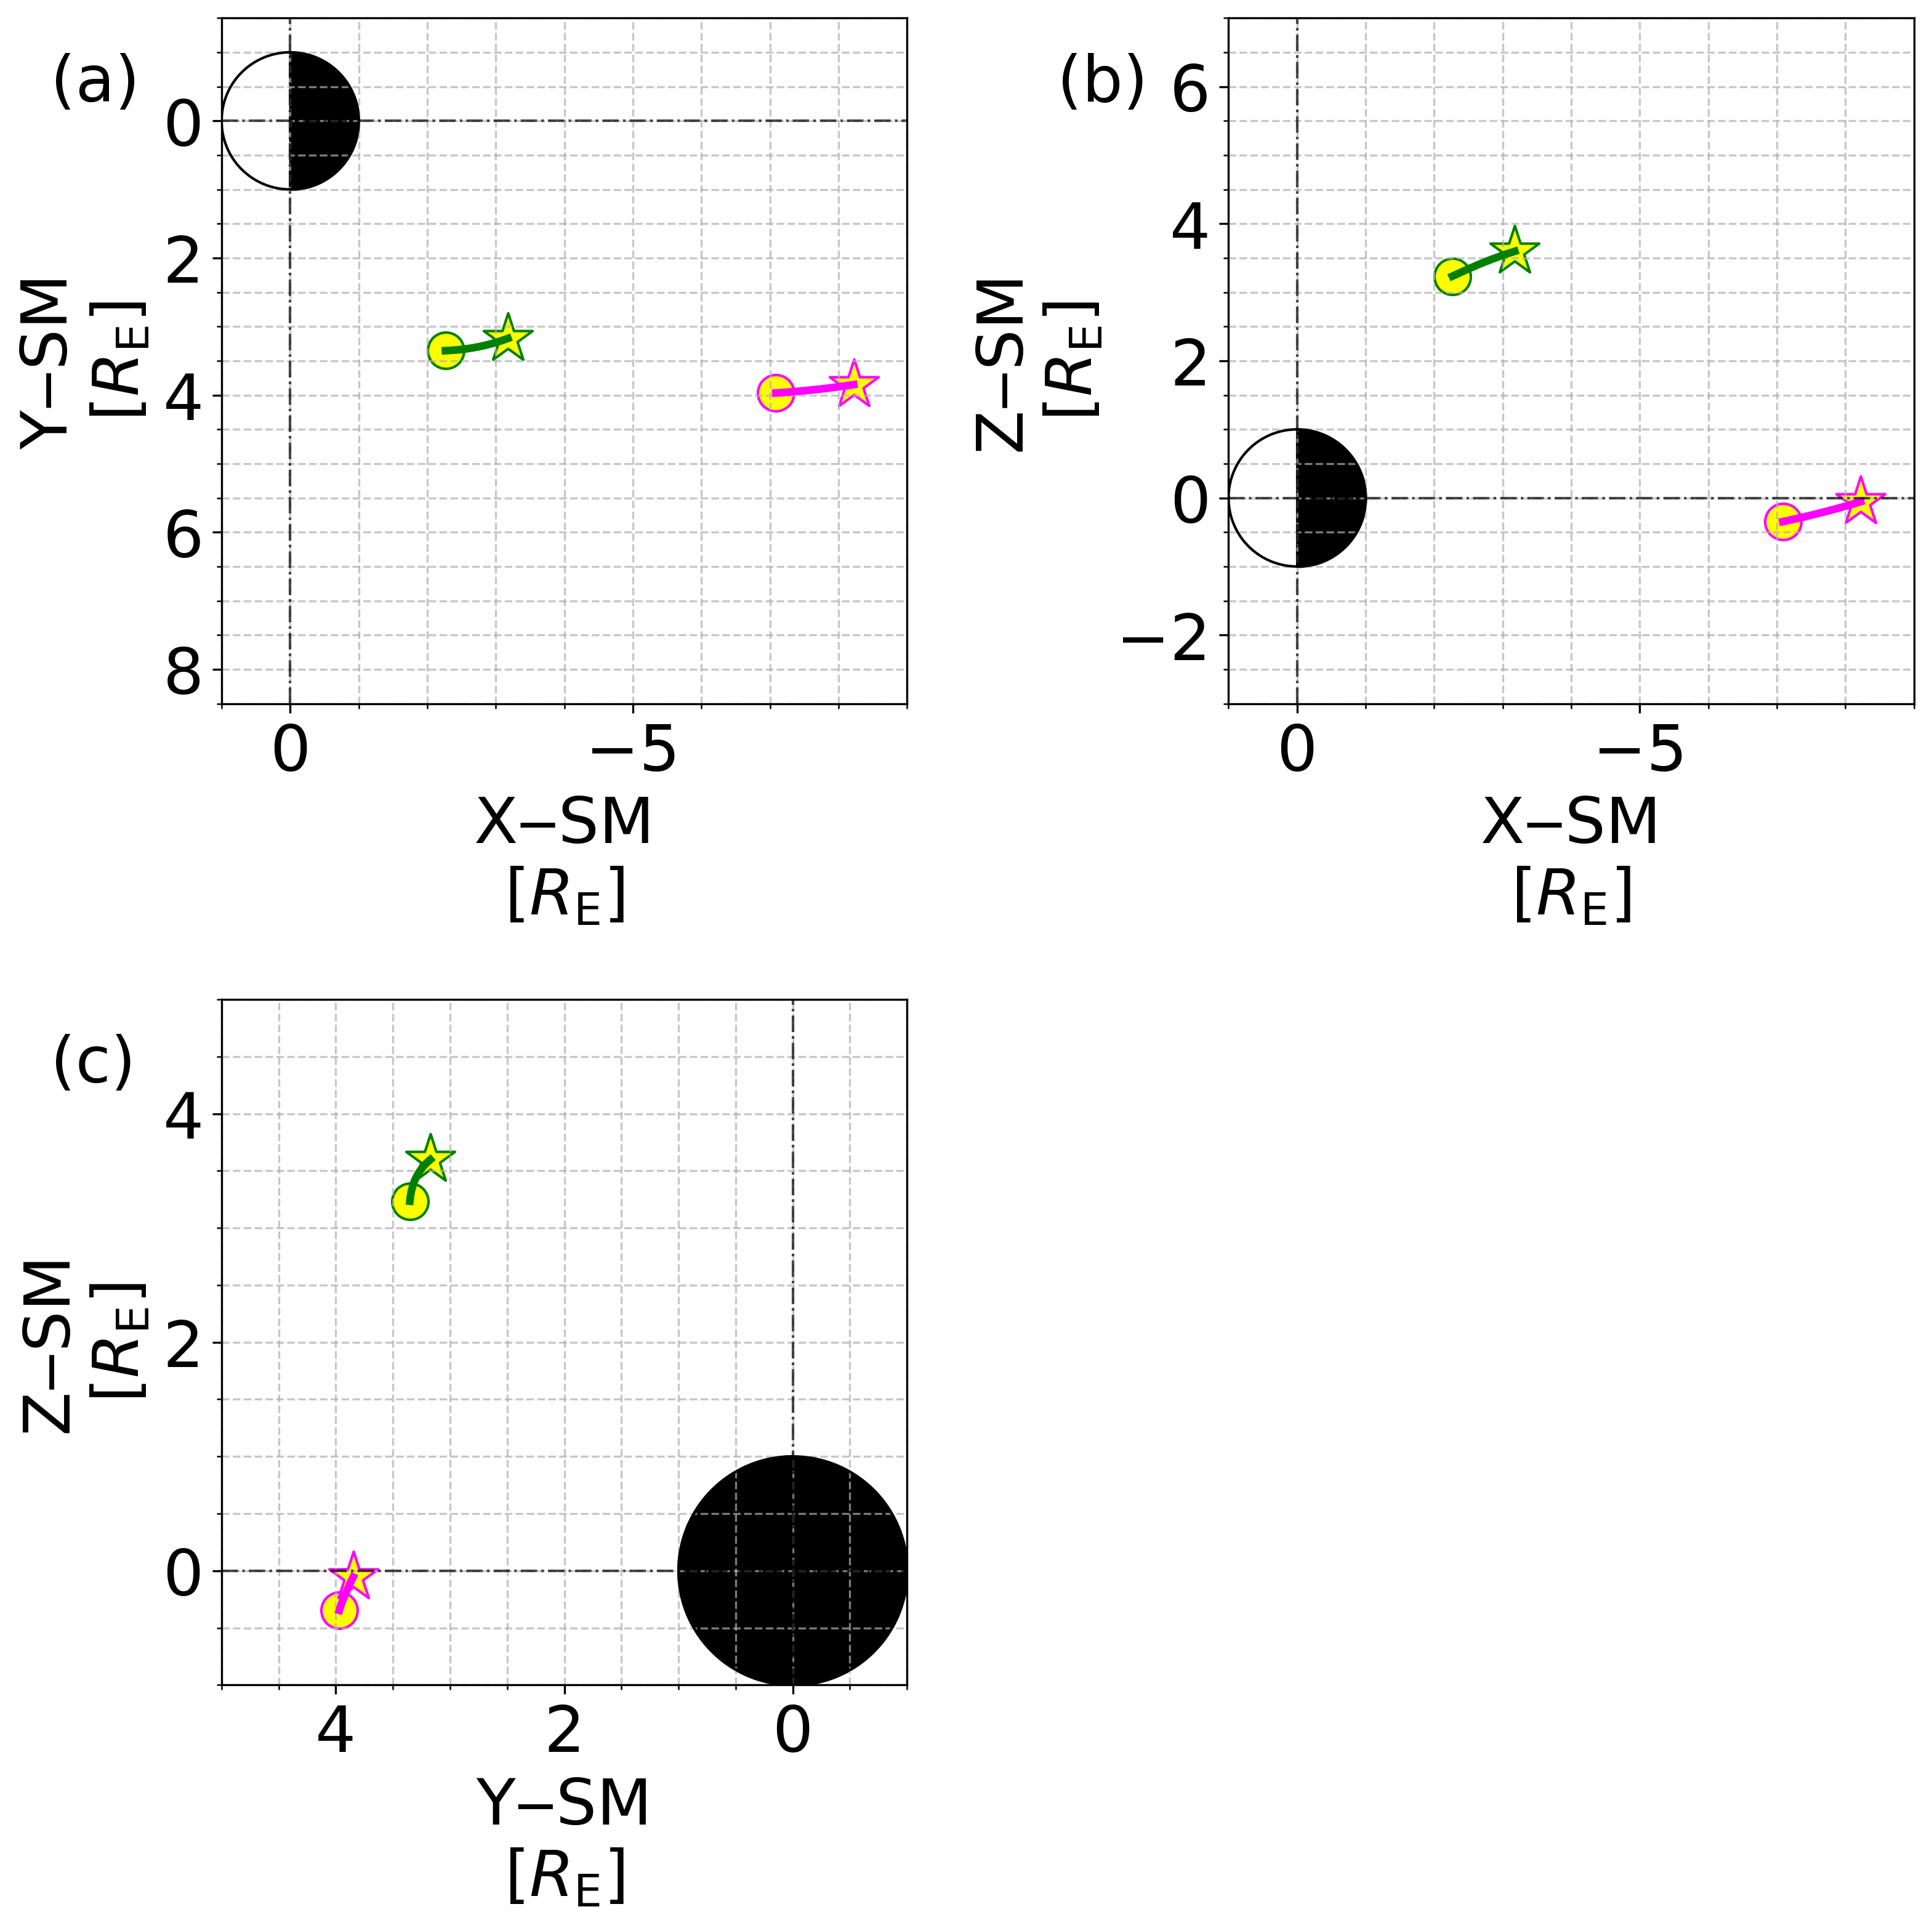

In [5]:
def pretty(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.minorticks_on()
    ax.grid(which='both', linestyle='--', alpha=0.7)
    ax.axhline(0, color='k', lw=1, linestyle='-.', alpha=0.7)
    ax.axvline(0, color='k', lw=1, linestyle='-.', alpha=0.7)
    ax.set_aspect('equal', 'box')

fig = plt.figure(figsize=(11, 11), dpi=300)

ax1 = fig.add_subplot(221)
ax1.plot(themis_a_pos_sm_x, themis_a_pos_sm_y, color='magenta', label='THEMIS-A', linewidth=3)
ax1.scatter(themis_a_pos_sm_x[0],  themis_a_pos_sm_y[0],  marker='o', c='yellow', s=200, edgecolors='magenta', linewidths=1)
ax1.scatter(themis_a_pos_sm_x[-1], themis_a_pos_sm_y[-1], marker='*', c='yellow', s=400, edgecolors='magenta', linewidths=1)
ax1.plot(Arase_pos_sm_x, Arase_pos_sm_y, color='green', label='Arase', linewidth=3)
ax1.scatter(Arase_pos_sm_x[0],  Arase_pos_sm_y[0],  marker='o', c='yellow', s=200, edgecolors='green', linewidths=1)
ax1.scatter(Arase_pos_sm_x[-1], Arase_pos_sm_y[-1], marker='*', c='yellow', s=400, edgecolors='green', linewidths=1)
pretty(ax1, 'X‒SM\n'+ r'[$R_{\mathrm{E}}$]', 'Y‒SM\n'+ r'[$R_{\mathrm{E}}$]')
ax1.set_xlim(1, -9)
ax1.set_ylim(8.5, -1.5)


ax2 = fig.add_subplot(222)
ax2.plot(themis_a_pos_sm_x, themis_a_pos_sm_z, color='magenta', label='THEMIS-A', linewidth=3)
ax2.scatter(themis_a_pos_sm_x[0],  themis_a_pos_sm_z[0],  marker='o', c='yellow', s=200, edgecolors='magenta', linewidths=1)
ax2.scatter(themis_a_pos_sm_x[-1], themis_a_pos_sm_z[-1], marker='*', c='yellow', s=400, edgecolors='magenta', linewidths=1)
ax2.plot(Arase_pos_sm_x, Arase_pos_sm_z, color='green', label='Arase', linewidth=3)
ax2.scatter(Arase_pos_sm_x[0],  Arase_pos_sm_z[0],  marker='o', c='yellow', s=200, edgecolors='green', linewidths=1)
ax2.scatter(Arase_pos_sm_x[-1], Arase_pos_sm_z[-1], marker='*', c='yellow', s=400, edgecolors='green', linewidths=1)
pretty(ax2, 'X‒SM\n'+ r'[$R_{\mathrm{E}}$]', 'Z‒SM\n'+ r'[$R_{\mathrm{E}}$]')
ax2.set_xlim(1, -9)
ax2.set_ylim(-3, 7)

ax3 = fig.add_subplot(223)
ax3.plot(themis_a_pos_sm_y, themis_a_pos_sm_z, color='magenta', label='THEMIS-A', linewidth=3)
ax3.scatter(themis_a_pos_sm_y[0],  themis_a_pos_sm_z[0],  marker='o', c='yellow', s=200, edgecolors='magenta', linewidths=1)
ax3.scatter(themis_a_pos_sm_y[-1], themis_a_pos_sm_z[-1], marker='*', c='yellow', s=400, edgecolors='magenta', linewidths=1)
ax3.plot(Arase_pos_sm_y, Arase_pos_sm_z, color='green', label='Arase', linewidth=3)
ax3.scatter(Arase_pos_sm_y[0],  Arase_pos_sm_z[0],  marker='o', c='yellow', s=200, edgecolors='green', linewidths=1)
ax3.scatter(Arase_pos_sm_y[-1], Arase_pos_sm_z[-1], marker='*', c='yellow', s=400, edgecolors='green', linewidths=1)
pretty(ax3, 'Y‒SM\n'+ r'[$R_{\mathrm{E}}$]', 'Z‒SM\n'+ r'[$R_{\mathrm{E}}$]')
ax3.set_xlim(5, -1)
ax3.set_ylim(-1, 5)

for ax in (ax1, ax2, ax3):
    th = np.linspace(0, 2*np.pi, 256)
    ax.plot(np.cos(th), np.sin(th), 'k-', lw=1, alpha=1)
    if ax == ax1 or ax == ax2:
        # 円の中のx<0の部分を塗りつぶす
        ax.fill_betweenx(np.sin(th), np.cos(th), 0, where=(np.cos(th)<0), color='k')
    if ax == ax3:
        # 円の中を塗りつぶす
        ax.fill_betweenx(np.sin(th), np.cos(th), 0, where=(np.cos(th)<0), color='k')
        ax.fill_betweenx(np.sin(th), np.cos(th), 0, where=(np.cos(th)>0), color='k')
    
    # 各図の外左上に(a-1) (a-2) (a-3) の文字を入れる
    if ax == ax1:
        ax.text(-0.25, 0.95, '(a)', transform=ax.transAxes, verticalalignment='top')
    elif ax == ax2:
        ax.text(-0.25, 0.95, '(b)', transform=ax.transAxes, verticalalignment='top')
    elif ax == ax3:
        ax.text(-0.25, 0.95, '(c)', transform=ax.transAxes, verticalalignment='top')

fig.tight_layout()
plt.show()

fig.savefig(r"/mnt/j/KAW_observation/Figure_1_a.pdf")

# 電子・proton omniflux, PA distribution

In [6]:
import pyspedas as psp
import pytplot as pt
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr

pt.del_data('*')

trange = ['2022-09-01/22:25', '2022-09-01/23:15']

psp.erg.lepe(trange=trange, level='l2', datatype='3dflux', no_update=True)
psp.erg.lepe(trange=trange, level='l2', datatype='omniflux', no_update=True)
psp.erg.lepi(trange=trange, level='l2', datatype='3dflux', no_update=True)
psp.erg.lepi(trange=trange, level='l2', datatype='omniflux', no_update=True)
psp.erg.mgf(trange=trange, level='l2', datatype='64hz', coord='dsi', no_update=True)
psp.erg.orb(trange=trange, level='l2', no_update=True)

24-Jan-26 22:38:28: Local file found: /mnt/j/observation_data//ergsc/satellite/erg/lepe/l2/3dflux/2022/09/erg_lepe_l2_3dflux_20220901_v04_01.cdf
24-Jan-26 22:38:40: Variable FEDU DEPEND_1 attribute FEDU_Energy has too many dimensions (3). Keeping extra dimensions (for now).
24-Jan-26 22:38:41: Variable Count_Rate DEPEND_1 attribute FEDU_Energy has too many dimensions (3). Keeping extra dimensions (for now).
24-Jan-26 22:38:41: Variable Count_Rate_BG DEPEND_1 attribute FEDU_Energy has too many dimensions (3). Keeping extra dimensions (for now).


 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Low-Energy Particle experiments - electron analyzer (LEP-e) Level 2 3D electron flux data']

Information about ERG LEPe

PI:  ['Shiang-Yu Wang']
Affiliation:  ['Academia Sinica, Taiwan']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of LEPe L2: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Lepe

Contact: erg_lepe_info at isee.nagoya-u.ac.jp
**************************************************************************


24-Jan-26 22:38:46: erg_lepe_l2_3dflux_FEDU contains negative values; setting the z-axis to log scale will cause the negative values to be ignored on figures.
24-Jan-26 22:38:47: Local file found: /mnt/j/observation_data//ergsc/satellite/erg/lepe/l2/omniflux/2022/09/erg_lepe_l2_omniflux_20220901_v04_01.cdf
24-Jan-26 22:38:47: Variable FEDO DEPEND_1 attribute FEDO_Energy has too many dimensions (3). Keeping extra dimensions (for now).


 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Low-Energy Particle experiments - electron analyzer (LEP-e) Level 2 omni electron flux data']

Information about ERG LEPe

PI:  ['Shiang-Yu Wang']
Affiliation:  ['Academia Sinica, Taiwan']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of LEPe L2: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Lepe

Contact: erg_lepe_info at isee.nagoya-u.ac.jp
**************************************************************************


24-Jan-26 22:38:48: Local file found: /mnt/j/observation_data//ergsc/satellite/erg/lepi/l2/3dflux/2022/09/erg_lepi_l2_3dflux_20220901_v03_00.cdf
24-Jan-26 22:39:01: Variable FPDU_Quality DEPEND_2 attribute FIDU_Channel has length 8, but corresponding data dimension has length 15. Removing attribute.
24-Jan-26 22:39:10: Variable FHEDU_Quality DEPEND_2 attribute FIDU_Channel has length 8, but corresponding data dimension has length 15. Removing attribute.
24-Jan-26 22:39:15: Variable FODU_Quality DEPEND_2 attribute FIDU_Channel has length 8, but corresponding data dimension has length 15. Removing attribute.
24-Jan-26 22:39:19: store_data: Data array for variable erg_lepi_l2_3dflux_FPDU_Quality has 4 dimensions, but only 1 v_n keys plus time. Adding empty v_n keys.
24-Jan-26 22:39:24: store_data: Data array for variable erg_lepi_l2_3dflux_FHEDU_Quality has 4 dimensions, but only 1 v_n keys plus time. Adding empty v_n keys.
24-Jan-26 22:39:27: store_data: Data array for variable erg_lepi_

...

24-Jan-26 22:39:35: Local file found: /mnt/j/observation_data//ergsc/satellite/erg/mgf/l2/64hz/2022/09/erg_mgf_l2_64hz_dsi_2022090122_v04.05.cdf
24-Jan-26 22:39:36: Local file found: /mnt/j/observation_data//ergsc/satellite/erg/mgf/l2/64hz/2022/09/erg_mgf_l2_64hz_dsi_2022090123_v04.05.cdf


 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Magnetic Field Experiment (MGF) Level 2 64 Hz resolution magnetic field data']

Information about ERG MGF

PI:  ['Ayako Matsuoka']
Affiliation:  ['Data Analysis Center for Geomagnetism and Space Magnetism, Graduate School of Science, Kyoto University, Kitashirakawa-Oiwake Cho, Sakyo-ku Kyoto 606-8502, Japan']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of MGF L2: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Mgf
Contact: erg_mgf_info at isee.nagoya-u.ac.jp
**************************************************************************


24-Jan-26 22:39:39: Local file found: /mnt/j/observation_data//ergsc/satellite/erg/orb/def/2022/erg_orb_l2_20220901_v05.cdf


 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Level-2 orbit data']

Information about ERG orbit


RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en

Contact: erg-sc-core at isee.nagoya-u.ac.jp
**************************************************************************


['erg_orb_l2_pos_llr',
 'erg_orb_l2_pos_gse',
 'erg_orb_l2_pos_gsm',
 'erg_orb_l2_pos_sm',
 'erg_orb_l2_pos_rmlatmlt',
 'erg_orb_l2_pos_eq',
 'erg_orb_l2_pos_iono_north',
 'erg_orb_l2_pos_iono_south',
 'erg_orb_l2_pos_blocal',
 'erg_orb_l2_pos_blocal_mag',
 'erg_orb_l2_pos_beq',
 'erg_orb_l2_pos_beq_mag',
 'erg_orb_l2_pos_Lm',
 'erg_orb_l2_vel_gse',
 'erg_orb_l2_vel_gsm',
 'erg_orb_l2_vel_sm',
 'erg_orb_l2_spn_num',
 'erg_orb_l2_man_prep_flag',
 'erg_orb_l2_man_on_flag',
 'erg_orb_l2_eclipse_flag']

In [7]:
background_time_sec = 100 #[sec]

In [8]:
import xarray as xr
import numpy as np

time_range_T    = [trange[0].replace('/', 'T'), trange[1].replace('/', 'T')]

B64_data_dsi    = pt.data_quants['erg_mgf_l2_mag_64hz_dsi'].sortby('time').sel(time=slice(time_range_T[0], time_range_T[1]))
B64_data_dsi_quality_flag   = pt.data_quants['erg_mgf_l2_quality_64hz'].sortby('time').sel(time=slice(time_range_T[0], time_range_T[1]))

qf_B, B64 = xr.align(B64_data_dsi_quality_flag[:, 3], B64_data_dsi, join='inner')

B64_data_dsi_qf = xr.where(qf_B <= 21, B64, np.nan)

ds_B64_dsi  = xr.Dataset({
    'B64_dsi_x':    B64_data_dsi_qf[:, 0],
    'B64_dsi_y':    B64_data_dsi_qf[:, 1],
    'B64_dsi_z':    B64_data_dsi_qf[:, 2]
})

ds_B64_dsi  = ds_B64_dsi.dropna(dim='time', how='all')

In [9]:
da_mgf_spin_phase_deg           = pt.data_quants['erg_mgf_l2_spin_phase_64hz'].sortby('time').sel(time=slice(time_range_T[0], time_range_T[1]))
da_mgf_spin_phase_deg_interp    = da_mgf_spin_phase_deg.interp(time=ds_B64_dsi.time)
da_mgf_spin_phase_rad_interp    = np.deg2rad(da_mgf_spin_phase_deg_interp)

In [10]:
import sys, importlib
importlib.invalidate_caches()
os.chdir('..')
print(os.getcwd())
import module_handmade.erg_mgf_spintone_rm as emsr
importlib.reload(emsr)
os.chdir('./KAW_observation')
print(os.getcwd())

B_clean_ndarray, B_spt_ndarray, params  = emsr.remove_spintone_3comp(
    time=ds_B64_dsi.time.values,
    Bx=ds_B64_dsi['B64_dsi_x'].values,
    By=ds_B64_dsi['B64_dsi_y'].values,
    Bz=ds_B64_dsi['B64_dsi_z'].values,
    phase_rad=da_mgf_spin_phase_rad_interp.values,
    min_points=64.*3./2.
)

ds_B64_dsi_spt      = xr.Dataset({
    'B64_dsi_x_spt':    ('time', B_spt_ndarray[:, 0]),
    'B64_dsi_y_spt':    ('time', B_spt_ndarray[:, 1]),
    'B64_dsi_z_spt':    ('time', B_spt_ndarray[:, 2])
    }, coords={'time': ds_B64_dsi.time.values})

ds_B64_dsi_clean    = xr.Dataset({
    'B64_dsi_x_clean':    ('time', B_clean_ndarray[:, 0]),
    'B64_dsi_y_clean':    ('time', B_clean_ndarray[:, 1]),
    'B64_dsi_z_clean':    ('time', B_clean_ndarray[:, 2])
    }, coords={'time': ds_B64_dsi.time.values})

print(ds_B64_dsi_spt)
print(ds_B64_dsi_clean)

/home/satanka/Documents/observation_workspace
/home/satanka/Documents/observation_workspace/KAW_observation
<xarray.Dataset> Size: 6MB
Dimensions:        (time: 195955)
Coordinates:
  * time           (time) datetime64[ns] 2MB 2022-09-01T22:25:00.006537984 .....
Data variables:
    B64_dsi_x_spt  (time) float64 2MB -82.34 -81.94 -81.52 ... 0.859 0.8643
    B64_dsi_y_spt  (time) float64 2MB 3.663 3.653 3.642 ... -0.5641 -0.5532
    B64_dsi_z_spt  (time) float64 2MB 31.68 31.52 31.37 ... 0.119 0.1213 0.1237
<xarray.Dataset> Size: 6MB
Dimensions:          (time: 195955)
Coordinates:
  * time             (time) datetime64[ns] 2MB 2022-09-01T22:25:00.006537984 ...
Data variables:
    B64_dsi_x_clean  (time) float64 2MB 385.3 384.8 384.3 ... 202.5 202.5 202.5
    B64_dsi_y_clean  (time) float64 2MB -16.7 -16.69 -16.7 ... -17.59 -17.63
    B64_dsi_z_clean  (time) float64 2MB -146.8 -146.6 -146.4 ... -141.0 -141.0


In [11]:
time_width_B64          = (ds_B64_dsi_clean.time[10] - ds_B64_dsi_clean.time[9]) / np.timedelta64(1, 's')
ds_B_background         = ds_B64_dsi_clean.rolling(time=int(background_time_sec / time_width_B64), center=True).mean('time')

da_B_background         = ds_B_background.to_dataarray(dim='v_dim').T.dropna(dim='time', how='any')

print(da_B_background)

<xarray.DataArray (time: 189587, v_dim: 3)> Size: 5MB
array([[ 298.3450957 ,  -13.58042665, -118.69769762],
       [ 298.33099127,  -13.579932  , -118.6938113 ],
       [ 298.3169661 ,  -13.57943411, -118.68995414],
       ...,
       [ 201.5921867 ,  -17.71568127, -141.50437158],
       [ 201.59226156,  -17.71572893, -141.50418969],
       [ 201.59232432,  -17.71578775, -141.50400216]], shape=(189587, 3))
Coordinates:
  * time     (time) datetime64[ns] 2MB 2022-09-01T22:25:49.727596928 ... 2022...
  * v_dim    (v_dim) object 24B 'B64_dsi_x_clean' ... 'B64_dsi_z_clean'


In [12]:
pt.store_data('erg_mgf_l2_mag_64hz_background_dsi', data={'x': da_B_background.time, 'y': da_B_background.data})

True

In [13]:
psp.projects.erg.erg_lep_part_products(
    'erg_lepe_l2_3dflux_FEDU',
    outputs=['pa'],
    pitch=[0, 180],
    energy=[40, 5000],
    mag_name='erg_mgf_l2_mag_64hz_background_dsi',
    pos_name='erg_orb_l2_pos_sm'
)

psp.projects.erg.erg_lep_part_products(
    'erg_lepi_l2_3dflux_FPDU',
    outputs=['pa'],
    pitch=[0, 180],
    energy=[40, 1000],
    mag_name='erg_mgf_l2_mag_64hz_background_dsi',
    pos_name='erg_orb_l2_pos_sm'
)

24-Jan-26 22:39:47: erg_mgf_l2_mag_64hz_background_dsi copied to erg_mgf_l2_mag_64hz_background_dsi_pgs_temp
24-Jan-26 22:39:47: tinterpol (linear) was applied to: erg_mgf_l2_mag_64hz_background_dsi_pgs_temp
24-Jan-26 22:39:47: erg_orb_l2_pos_sm copied to erg_orb_l2_pos_sm_pgs_temp
24-Jan-26 22:39:47: tinterpol (linear) was applied to: erg_orb_l2_pos_sm_pgs_temp
24-Jan-26 22:39:47: erg_orb_l2_pos_sm_pgs_temp copied to pos_pgs_temp
24-Jan-26 22:39:47: ['gse', 'gsm', 'sm']
24-Jan-26 22:39:47: Running transformation: subgse2gsm
24-Jan-26 22:39:47: Running transformation: subgsm2sm
24-Jan-26 22:39:47: Setting coordinate system for pos_pgs_temp
24-Jan-26 22:39:47: Output variable: pos_pgs_temp
24-Jan-26 22:39:47: ['sm', 'gsm', 'gse', 'gei', 'j2000']
24-Jan-26 22:39:47: Running transformation: subsm2gsm
24-Jan-26 22:39:47: Running transformation: subgsm2gse
24-Jan-26 22:39:47: Running transformation: subgse2gei
24-Jan-26 22:39:47: Running transformation: subgei2j2000
24-Jan-26 22:39:47: Sett

 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Level-2 orbit data']

Information about ERG orbit


RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en

Contact: erg-sc-core at isee.nagoya-u.ac.jp
**************************************************************************
J2000 --> DSI


24-Jan-26 22:40:00: erg_mgf_l2_mag_64hz_background_dsi copied to erg_mgf_l2_mag_64hz_background_dsi_pgs_temp
24-Jan-26 22:40:00: tinterpol (linear) was applied to: erg_mgf_l2_mag_64hz_background_dsi_pgs_temp
24-Jan-26 22:40:00: erg_orb_l2_pos_sm copied to erg_orb_l2_pos_sm_pgs_temp
24-Jan-26 22:40:00: tinterpol (linear) was applied to: erg_orb_l2_pos_sm_pgs_temp
24-Jan-26 22:40:00: erg_orb_l2_pos_sm_pgs_temp copied to pos_pgs_temp
24-Jan-26 22:40:00: ['gse', 'gsm', 'sm']
24-Jan-26 22:40:01: Running transformation: subgse2gsm
24-Jan-26 22:40:01: Running transformation: subgsm2sm
24-Jan-26 22:40:01: Setting coordinate system for pos_pgs_temp
24-Jan-26 22:40:01: Output variable: pos_pgs_temp
24-Jan-26 22:40:01: ['sm', 'gsm', 'gse', 'gei', 'j2000']
24-Jan-26 22:40:01: Running transformation: subsm2gsm
24-Jan-26 22:40:01: Running transformation: subgsm2gse
24-Jan-26 22:40:01: Running transformation: subgse2gei
24-Jan-26 22:40:01: Running transformation: subgei2j2000
24-Jan-26 22:40:01: Sett

 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Level-2 orbit data']

Information about ERG orbit


RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en

Contact: erg-sc-core at isee.nagoya-u.ac.jp
**************************************************************************


24-Jan-26 22:40:08: tinterpol (linear) was applied to: erg_orb_l2_pos_gse-itrp
24-Jan-26 22:40:08: ['gse', 'gei', 'j2000']
24-Jan-26 22:40:08: Running transformation: subgse2gei
24-Jan-26 22:40:08: Running transformation: subgei2j2000
24-Jan-26 22:40:08: Setting coordinate system for sundir_j2000
24-Jan-26 22:40:08: Output variable: sundir_j2000


J2000 --> DSI


24-Jan-26 22:40:13: erg_lepi_l2_3dflux_FPDU is 15% done.
24-Jan-26 22:40:18: erg_lepi_l2_3dflux_FPDU is 27% done.
24-Jan-26 22:40:23: erg_lepi_l2_3dflux_FPDU is 39% done.
24-Jan-26 22:40:28: erg_lepi_l2_3dflux_FPDU is 50% done.
24-Jan-26 22:40:33: erg_lepi_l2_3dflux_FPDU is 64% done.
24-Jan-26 22:40:38: erg_lepi_l2_3dflux_FPDU is 76% done.
24-Jan-26 22:40:43: erg_lepi_l2_3dflux_FPDU is 85% done.
24-Jan-26 22:40:48: erg_lepi_l2_3dflux_FPDU is 96% done.


['erg_lepi_l2_3dflux_FPDU_pa']

In [14]:
mpl.rcParams['font.size'] = 20

1.0 10000.0
(382, 30)
(382, 30)
(382, 30)
1.0 10000.0
(382, 16)
(382, 16)
(382, 16)
100.0 100000.0
(382, 28)
(382, 28)
(382, 28)
100.0 100000.0
(374, 16)
(374, 16)
(374, 16)


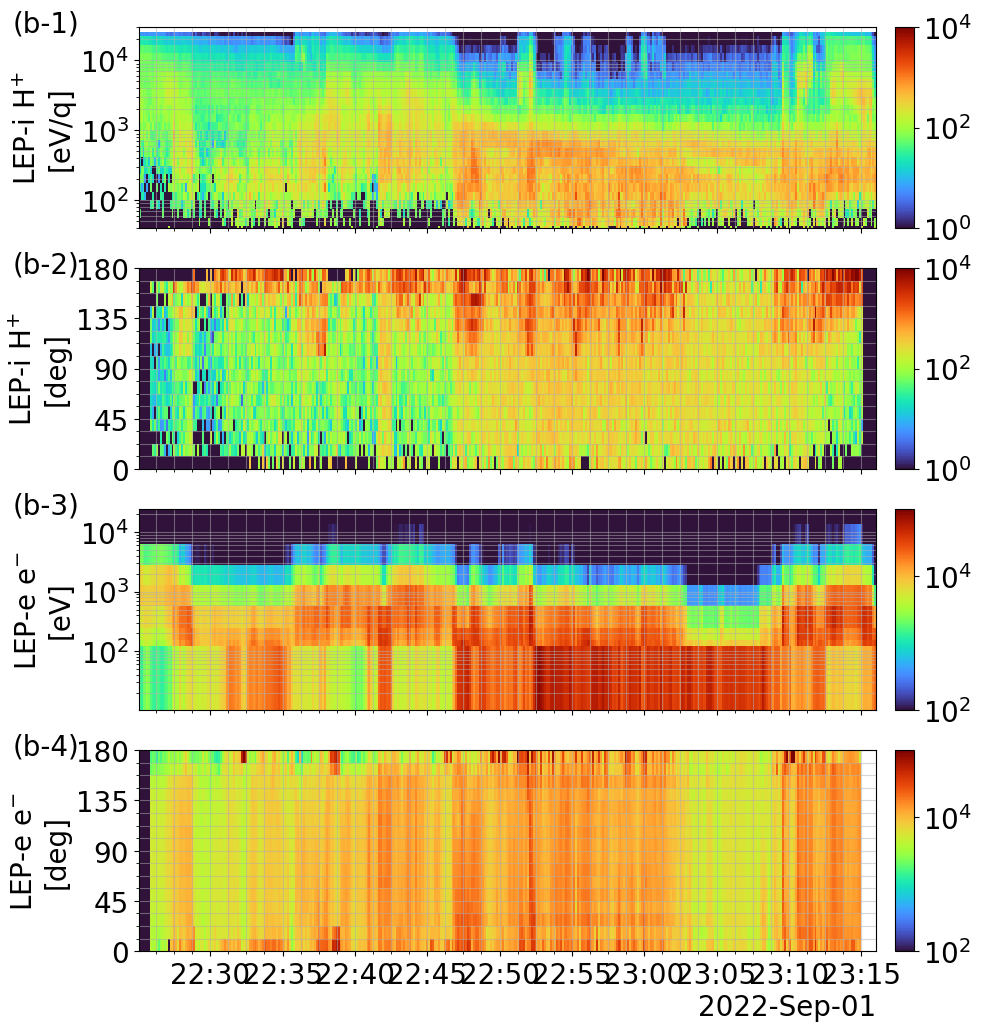

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import pytplot as pt

def omniflux_plot_Arase(inst_name, fig, ax, cax, dq, vmin=None, vmax=None, energy_min=None, energy_max=None, ytitle=None, ztitle=None):
    # 取り出し（全て (T, E) 形状）
    flux = np.asarray(dq.data, dtype=float)           # (T, E)
    if inst_name == 'lepe':
        E    = np.asarray(dq.spec_bins, dtype=float)      # (T, E) 変動エネルギー
    elif inst_name == 'lepi':
        E    = np.asarray(dq.spec_bins, dtype=float)      # (E) 変動エネルギー
        E    = E * 1E3                                     # keV → eV
        E    = np.broadcast_to(E[None, :], flux.shape)      # (T, E)
    t    = np.asarray(dq.time.values)                 # (T,)

    # pcolormeshのX/Yは非有限NG → 列方向で全部有限なチャンネルだけ残す
    good_e = np.all(~np.isnan(E), axis=0)
    if not np.all(good_e):
        flux = flux[:, good_e]
        E    = E[:,    good_e]

    # ---- 値の前処理（LogNorm 用）----
    flux[~np.isfinite(flux)] = np.nan
    flux[flux <= 0] = np.nan
    if np.all(~np.isfinite(flux)):
        raise ValueError("有効な（>0）フラックスがありません。")

    if vmin == None:
        vmin = np.nanmin(flux)
    if vmax == None:
        vmax = np.nanmax(flux)
    if not (vmin < vmax):
        vmax = vmin * 1.0001
    norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
    print(vmin, vmax)

    flux[np.isnan(flux)] = 1E-99

    # ---- 時間メッシュ生成（(T,E)）----
    Tmesh = np.broadcast_to(t[:, None], E.shape)

    print(flux.shape)
    print(E.shape)
    print(Tmesh.shape)

    # ---- 描画 ----
    mesh = ax.pcolormesh(Tmesh, E, flux, norm=norm, cmap=cm.turbo, shading='nearest')
    cb = fig.colorbar(mesh, cax=cax)
    cb.set_label("")  # ラベル消す
    #if ztitle:
    #    ax.text(0.85, 0.15, ztitle,
    #            transform=ax.transAxes, ha='center', va='center', color='k',
    #            bbox=dict(facecolor='white', alpha=0.5, boxstyle='round,pad=0.25'))

    ax.set_yscale('log')
    ax.set_ylabel(ytitle)
    ax.grid(which='both', alpha=0.5)
    ax.minorticks_on()

    if energy_min != None:
        ax.set_ylim(ymin=energy_min)
    if energy_max != None:
        ax.set_ylim(ymax=energy_max)

    # 時刻目盛り
    loc = mdates.AutoDateLocator()
    fmt = mdates.ConciseDateFormatter(loc)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(fmt)

    return fig, ax, cax

def pa_plot_Arase(fig, ax, cax, dq, vmin=None, vmax=None, ytitle=None, ztitle=None):
    # 取り出し（全て (T, E) 形状）
    flux = np.asarray(dq.data, dtype=float)           # (T, E)
    PA    = np.asarray(dq.spec_bins, dtype=float)     # (T, E)
    t    = np.asarray(dq.time.values)                 # (T,)

    # pcolormeshのX/Yは非有限NG → 列方向で全部有限なチャンネルだけ残す
    good_PA = np.all(~np.isnan(PA), axis=0)
    if not np.all(good_PA):
        flux = flux[:, good_PA]
        PA    = PA[:,    good_PA]

    # ---- 値の前処理（LogNorm 用）----
    flux[~np.isfinite(flux)] = np.nan
    flux[flux <= 0] = np.nan
    if np.all(~np.isfinite(flux)):
        raise ValueError("有効な（>0）フラックスがありません。")

    if vmin == None:
        vmin = np.nanmin(flux)
    if vmax == None:
        vmax = np.nanmax(flux)
    if not (vmin < vmax):
        vmax = vmin * 1.0001
    norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
    print(vmin, vmax)

    flux[np.isnan(flux)] = 1E-99

    # ---- 時間メッシュ生成（(T,E)）----
    Tmesh = np.broadcast_to(t[:, None], PA.shape)

    print(flux.shape)
    print(PA.shape)
    print(Tmesh.shape)

    # ---- 描画 ----
    mesh = ax.pcolormesh(Tmesh, PA, flux, norm=norm, cmap=cm.turbo, shading='nearest')
    cb = fig.colorbar(mesh, cax=cax)
    cb.set_label("")  # ラベル消す
    #if ztitle:
    #    ax.text(0.85, 0.5, ztitle,
    #            transform=ax.transAxes, ha='center', va='center', color='k',
    #            bbox=dict(facecolor='white', alpha=0.5, boxstyle='round,pad=0.25'))

    ax.set_ylabel(ytitle)
    ax.grid(which='both', alpha=0.5)
    ax.minorticks_on()

    ax.set_ylim(ymax=180, ymin=0)
    ax.set_yticks(np.arange(0, 181, 45))

    # 時刻目盛り
    loc = mdates.AutoDateLocator()
    fmt = mdates.ConciseDateFormatter(loc)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(fmt)

    return fig, ax, cax

def add_panel_label(ax, label, x=-0.08, y=0.95):
    ax.text(x, y, label, transform=ax.transAxes,
            ha='right', va='bottom', clip_on=False)

fig = plt.figure(figsize=(10, 12))
gs = fig.add_gridspec(4, 2, width_ratios=[1, 0.025], wspace=0.05)
ax_1 = fig.add_subplot(gs[0, 0])
cax_1 = fig.add_subplot(gs[0, 1])
ax_2 = fig.add_subplot(gs[1, 0], sharex=ax_1)
cax_2 = fig.add_subplot(gs[1, 1])
ax_3 = fig.add_subplot(gs[2, 0], sharex=ax_1)
cax_3 = fig.add_subplot(gs[2, 1])
ax_4 = fig.add_subplot(gs[3, 0], sharex=ax_1)
cax_4 = fig.add_subplot(gs[3, 1])

ax_1.tick_params(axis='x', which='both', labelbottom=False)
ax_2.tick_params(axis='x', which='both', labelbottom=False)
ax_3.tick_params(axis='x', which='both', labelbottom=False)

dq_proton = pt.data_quants['erg_lepi_l2_omniflux_FPDO'].sel(time=slice(*trange)) * 1E-3 # '#/s/$cm^{2}$/str/eV'
dq_proton_pa = pt.data_quants['erg_lepi_l2_3dflux_FPDU_pa'].sel(time=slice(*trange))    #'#/s/$cm^{2}$/str/eV'

dq_electron = pt.data_quants['erg_lepe_l2_omniflux_FEDO'].sel(time=slice(*trange))      #'#/s/$cm^{2}$/str/eV'
dq_electron_pa = pt.data_quants['erg_lepe_l2_3dflux_FEDU_pa'].sel(time=slice(*trange))  #'#/s/$cm^{2}$/str/eV'

ytitle_proton = r'LEP-i $\mathrm{H}^{+}$' + '\n' + r'[eV/q]'
ztitle_proton = r'[$\mathrm{cm}^{-2} \mathrm{sr}^{-1} \mathrm{s}^{-1} \mathrm{eV}^{-1}$]'
omniflux_plot_Arase('lepi', fig, ax_1, cax_1, dq_proton, 1E0, 1E4, 4E1, 3E4, ytitle_proton, ztitle_proton)

ytitle_proton_pa = r'LEP-i $\mathrm{H}^{+}$' + '\n' + r'[deg]'
ztitle_proton_pa = r'[$\mathrm{cm}^{-2} \mathrm{sr}^{-1} \mathrm{s}^{-1} \mathrm{eV}^{-1}$]'
pa_plot_Arase(fig, ax_2, cax_2, dq_proton_pa, 1E0, 1E4, ytitle_proton_pa, ztitle_proton_pa)

ytitle_electron = r'LEP-e $\mathrm{e}^{-}$' + '\n' + r'[eV]'
ztitle_electron = r'[$\mathrm{cm}^{-2} \mathrm{sr}^{-1} \mathrm{s}^{-1} \mathrm{eV}^{-1}$]'
omniflux_plot_Arase('lepe', fig, ax_3, cax_3, dq_electron, 1E2, 1E5, None, None, ytitle_electron, ztitle_electron)

ytitle_electron_pa = r'LEP-e $\mathrm{e}^{-}$' + '\n' + r'[deg]'
ztitle_electron_pa = r'[$\mathrm{cm}^{-2} \mathrm{sr}^{-1} \mathrm{s}^{-1} \mathrm{eV}^{-1}$]'
pa_plot_Arase(fig, ax_4, cax_4, dq_electron_pa, 1E2, 1E5, ytitle_electron_pa, ztitle_electron_pa)

add_panel_label(ax_1, '(b-1)')
add_panel_label(ax_2, '(b-2)')
add_panel_label(ax_3, '(b-3)')
add_panel_label(ax_4, '(b-4)')

plt.tight_layout()
plt.show()

In [16]:
psp.themis.esa(trange=trange, probe='a', level='l2', no_update=True)

themis_a_e_omniflux = pt.data_quants['tha_peeb_en_eflux']
themis_a_e_omniflux = themis_a_e_omniflux.sel(time=slice(trange[0], trange[1]))
print(themis_a_e_omniflux)

themis_a_proton_omniflux = pt.data_quants['tha_peib_en_eflux']
themis_a_proton_omniflux = themis_a_proton_omniflux.sel(time=slice(trange[0], trange[1]))
print(themis_a_proton_omniflux)

24-Jan-26 22:40:52: Local file found: /mnt/j/observation_data//themis/tha/l2/esa/2022/tha_l2_esa_20220901_v01.cdf
24-Jan-26 22:40:54: Variable tha_peer_symm_angQ not marked as VIRTUAL, but has FUNCT and COMPONENT_0 attributes; skipping
24-Jan-26 22:40:54: Variable tha_peer_magfQ not marked as VIRTUAL, but has FUNCT and COMPONENT_0 attributes; skipping
24-Jan-26 22:40:54: Variable tha_peer_velocity_dslQ not marked as VIRTUAL, but has FUNCT and COMPONENT_0 attributes; skipping
24-Jan-26 22:40:54: Variable tha_peer_velocity_gseQ not marked as VIRTUAL, but has FUNCT and COMPONENT_0 attributes; skipping
24-Jan-26 22:40:54: Variable tha_peer_velocity_gsmQ not marked as VIRTUAL, but has FUNCT and COMPONENT_0 attributes; skipping
24-Jan-26 22:40:54: Variable tha_peer_modeQ not marked as VIRTUAL, but has FUNCT and COMPONENT_0 attributes; skipping


<xarray.DataArray 'tha_peeb_en_eflux' (time: 502, v_dim: 32)> Size: 129kB
array([[           nan, 1.00692444e+06, 9.67856812e+05, ...,
        5.40237480e+07, 9.44177520e+07, 1.13930400e+08],
       [           nan, 8.85697000e+05, 7.86126438e+05, ...,
        5.39849640e+07, 8.83432080e+07, 1.16470408e+08],
       [           nan, 8.19676375e+05, 8.03513625e+05, ...,
        5.64620640e+07, 8.95397280e+07, 1.15000544e+08],
       ...,
       [           nan, 1.17009225e+06, 1.36001862e+06, ...,
        1.34857200e+06, 7.29667950e+06, 4.54480240e+07],
       [           nan, 1.16001825e+06, 1.16340288e+06, ...,
        1.21714388e+06, 9.35635500e+06, 5.86444560e+07],
       [           nan, 1.59648725e+06, 1.46589612e+06, ...,
        1.32255412e+06, 8.66207500e+06, 5.33033960e+07]], shape=(502, 32))
Coordinates:
  * time       (time) datetime64[ns] 4kB 2022-09-01T22:28:45.593852160 ... 20...
    spec_bins  (time, v_dim) float32 64kB 3.177e+04 2.683e+04 ... 9.21 7.271
    v          (t

In [17]:
import os

import sys, importlib
from pathlib import Path

ROOT = Path("/home/satanka/Documents/observation_workspace")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import module_handmade.themis_band_dnumflux as tbd
importlib.reload(tbd)

tbd.compute_band_dnumflux(
    folder=r'/mnt/j/observation_data/themis/tha/idl_output/per_bin',
    spec='peif',
    Emin=40,
    Emax=1000
)

tbd.compute_band_dnumflux(
    folder=r'/mnt/j/observation_data/themis/tha/idl_output/per_bin',
    spec='peef',
    Emin=40,
    Emax=5000
)

'/mnt/j/observation_data/themis/tha/idl_output/per_bin/tha_peef_dnumflux_E40to5000.csv'

In [18]:
import pandas as pd, numpy as np, xarray as xr

def csv_to_xarray_dnumflux(csv_path: str, var_name: str = "dnumflux"):
    df = pd.read_csv(csv_path)
    if "time_iso" not in df.columns:
        raise ValueError("CSVに'time_iso'列が必要です。")
    # ピッチ角中心（列名）→ spec_bins 座標
    pa_cols = [c for c in df.columns if c != "time_iso"]
    pa_vals = np.array([float(c) for c in pa_cols])  # 度

    # 時間
    time = pd.to_datetime(df["time_iso"], format="%Y-%m-%d/%H:%M:%S", errors="coerce").to_numpy()

    # データ (len(time), len(pitch_angle))
    data = df[pa_cols].to_numpy(dtype=float)

    da = xr.DataArray(
        data,
        dims=("time", "spec_bins"),
        coords={"time": time, "spec_bins": pa_vals},
        name=var_name,
        attrs={
            "units": "1/(cm^2 sr s eV)",
            "long_name": "band-averaged differential number flux",
        }
    )
    return da

da_tha_proton_pa = csv_to_xarray_dnumflux(
    r"/mnt/j/observation_data/themis/tha/idl_output/per_bin/tha_peif_dnumflux_E40to1000.csv",
    var_name="tha_peif_dnumflux_E40to1000"
    )

da_tha_electron_pa = csv_to_xarray_dnumflux(
    r"/mnt/j/observation_data/themis/tha/idl_output/per_bin/tha_peef_dnumflux_E40to5000.csv",
    var_name="tha_peef_dnumflux_E40to5000"
    )

print(da_tha_proton_pa)
print(da_tha_electron_pa)

<xarray.DataArray 'tha_peif_dnumflux_E40to1000' (time: 39, spec_bins: 8)> Size: 2kB
array([[ 445.56836731,  246.98194063,  118.25597871,  132.4819722 ,
         138.89750878,  214.56450718,  300.80194921,  481.14456262],
       [ 319.20343757,  398.70740512,  365.57419504,  494.81574678,
         534.43045965,  648.29848187,  656.31575705,  617.72879675],
       [ 263.41927625,  189.72121164,  217.97703721,  210.4995486 ,
         169.11437763,  173.39030275,  156.06676433,  301.85479196],
       [1093.54010701,  445.55350996,  280.37464395,  280.33602473,
         290.9966498 ,  393.9216191 ,  605.66310498, 1052.65163149],
       [ 172.35605829,  189.86423376,  169.0196023 ,  173.62502684,
         166.79165794,  172.39952771,  156.54757676,  165.68012322],
       [ 101.78177444,  152.14377545,  137.069198  ,   96.63664084,
         101.63083568,   90.70469569,  121.0956128 ,  241.33608203],
       [ 165.52405713,  137.7608755 ,  154.42372771,  164.05895334,
         228.98813185,  19

In [19]:
da_tha_proton = pt.data_quants['tha_peif_en_eflux']
da_tha_electron = pt.data_quants['tha_peef_en_eflux']

print(da_tha_proton)
print(da_tha_electron)

import os
import sys
import importlib

ROOT = Path("/home/satanka/Documents/observation_workspace")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import module_handmade.xarray_numflux_utils as xnu
importlib.reload(xnu)

dn_tha_proton = xnu.eflux_to_numflux(da_eflux=da_tha_proton)
dn_tha_electron = xnu.eflux_to_numflux(da_eflux=da_tha_electron)

print(dn_tha_proton)
print(dn_tha_electron)

<xarray.DataArray 'tha_peif_en_eflux' (time: 965, v_dim: 32)> Size: 247kB
array([[           nan, 1.09935788e+06, 1.02114181e+06, ...,
        1.23583662e+04, 6.08744092e+03, 0.00000000e+00],
       [           nan, 1.30430500e+06, 1.04760762e+06, ...,
        6.14860938e+03, 2.21859326e+03, 5.00147607e+03],
       [           nan, 1.07117750e+06, 8.99695625e+05, ...,
        0.00000000e+00, 5.11336133e+03, 1.11797627e+04],
       ...,
       [           nan, 1.50505925e+06, 1.48155238e+06, ...,
        0.00000000e+00, 4.08127832e+03, 4.54654004e+03],
       [           nan, 1.45921988e+06, 1.28189588e+06, ...,
        1.06699756e+03, 3.08156934e+03, 4.63757617e+03],
       [           nan, 1.60626250e+06, 1.42896888e+06, ...,
        2.06512012e+03, 0.00000000e+00, 2.19200781e+03]], shape=(965, 32))
Coordinates:
  * time       (time) datetime64[ns] 8kB 2022-09-01T00:00:50.197822208 ... 20...
    spec_bins  (time, v_dim) float32 124kB 2.521e+04 2.13e+04 ... 7.31 5.771
    v          (t

24-Jan-26 22:41:21: /tmp/ipykernel_30032/793464723.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



[[ 445.56836731  246.98194063  118.25597871  132.4819722   138.89750878
   214.56450718  300.80194921  481.14456262]
 [ 319.20343757  398.70740512  365.57419504  494.81574678  534.43045965
   648.29848187  656.31575705  617.72879675]
 [ 263.41927625  189.72121164  217.97703721  210.4995486   169.11437763
   173.39030275  156.06676433  301.85479196]
 [1093.54010701  445.55350996  280.37464395  280.33602473  290.9966498
   393.9216191   605.66310498 1052.65163149]
 [ 172.35605829  189.86423376  169.0196023   173.62502684  166.79165794
   172.39952771  156.54757676  165.68012322]
 [ 101.78177444  152.14377545  137.069198     96.63664084  101.63083568
    90.70469569  121.0956128   241.33608203]
 [ 165.52405713  137.7608755   154.42372771  164.05895334  228.98813185
   192.67297448  211.29145142  241.03451905]
 [ 208.97455296  193.96973224  159.71876719  173.65177572  154.80144747
   185.19934734  168.61015493  244.74624591]
 [ 201.19943988  154.40668772  180.83379518  149.40053247  159.31

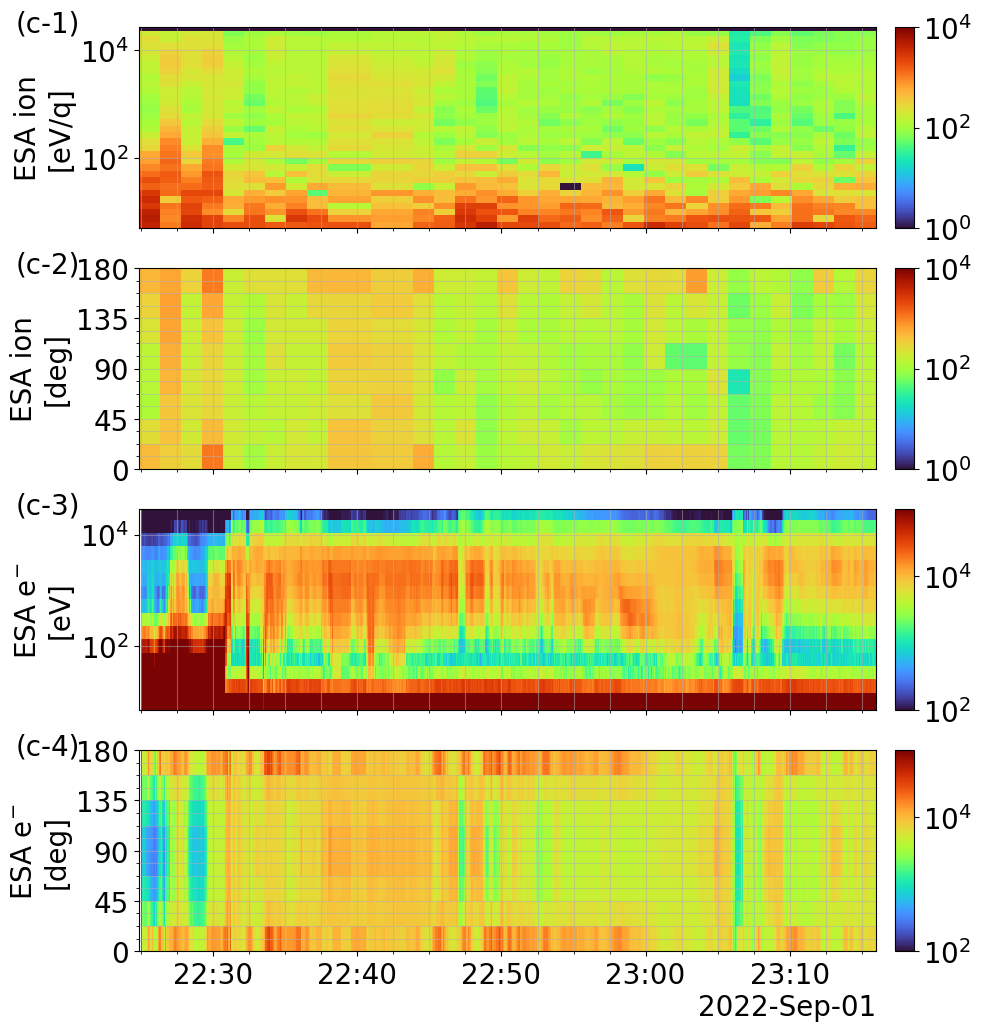

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import pytplot as pt

def omniflux_plot_THEMIS_A(fig, ax, cax, dq, vmin=None, vmax=None, energy_min=None, energy_max=None, ytitle=None, ztitle=None):
    # 取り出し（全て (T, E) 形状）
    flux = np.asarray(dq.data, dtype=float)           # (T, E)
    E    = np.asarray(dq.spec_bins, dtype=float)      # (T, E) 変動エネルギー
    t    = np.asarray(dq.time.values)                 # (T,)

    # pcolormeshのX/Yは非有限NG → 列方向で全部有限なチャンネルだけ残す
    good_e = np.all(~np.isnan(E), axis=0)
    if not np.all(good_e):
        flux = flux[:, good_e]
        E    = E[:,    good_e]

    # ---- 値の前処理（LogNorm 用）----
    flux[~np.isfinite(flux)] = np.nan
    flux[flux <= 0] = np.nan
    if np.all(~np.isfinite(flux)):
        raise ValueError("有効な（>0）フラックスがありません。")

    if vmin == None:
        vmin = np.nanmin(flux)
    if vmax == None:
        vmax = np.nanmax(flux)
    if not (vmin < vmax):
        vmax = vmin * 1.0001
    norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
    #print(vmin, vmax)

    flux[np.isnan(flux)] = 1E-99

    # ---- 時間メッシュ生成（(T,E)）----
    Tmesh = np.broadcast_to(t[:, None], E.shape)

    #print(flux.shape)
    #print(E.shape)
    #print(Tmesh.shape)

    # ---- 描画 ----
    mesh = ax.pcolormesh(Tmesh, E, flux, norm=norm, cmap=cm.turbo, shading='nearest')
    cb = fig.colorbar(mesh, cax=cax)
    cb.set_label("")  # ラベル消す
    #if ztitle:
    #    ax.text(0.85, 0.15, ztitle,
    #            transform=ax.transAxes, ha='center', va='center', color='k',
    #            bbox=dict(facecolor='white', alpha=0.5, boxstyle='round,pad=0.25'))

    ax.set_yscale('log')
    ax.set_ylabel(ytitle)
    ax.grid(which='both', alpha=0.5)
    ax.minorticks_on()

    if energy_min != None:
        ax.set_ylim(ymin=energy_min)
    if energy_max != None:
        ax.set_ylim(ymax=energy_max)

    # 時刻目盛り
    loc = mdates.AutoDateLocator()
    fmt = mdates.ConciseDateFormatter(loc)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(fmt)

    return fig, ax, cax

def pa_plot_THEMIS_A(fig, ax, cax, dq, vmin=None, vmax=None, ytitle=None, ztitle=None):
    # 取り出し（全て (T, E) 形状）
    flux = np.asarray(dq.data, dtype=float)           # (T, E)
    PA    = np.asarray(dq.spec_bins, dtype=float)     # (E)
    PA    = np.broadcast_to(PA[None, :], flux.shape)  # (T, E)
    t    = np.asarray(dq.time.values)                 # (T,)
    print(flux)

    # pcolormeshのX/Yは非有限NG → 列方向で全部有限なチャンネルだけ残す
    good_PA = np.all(~np.isnan(PA), axis=0)
    if not np.all(good_PA):
        flux = flux[:, good_PA]
        PA    = PA[:,    good_PA]

    # ---- 値の前処理（LogNorm 用）----
    flux[~np.isfinite(flux)] = np.nan
    flux[flux <= 0] = np.nan
    if np.all(~np.isfinite(flux)):
        raise ValueError("有効な（>0）フラックスがありません。")

    if vmin == None:
        vmin = np.nanmin(flux)
    if vmax == None:
        vmax = np.nanmax(flux)
    if not (vmin < vmax):
        vmax = vmin * 1.0001
    norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
    #print(vmin, vmax)

    flux[np.isnan(flux)] = 1E-99

    # ---- 時間メッシュ生成（(T,E)）----
    print(t.shape)
    if t.shape == flux.shape:
        Tmesh = t
    else:
        Tmesh = np.broadcast_to(t[:, None], flux.shape)

    #print(flux.shape)
    #print(PA.shape)
    #print(Tmesh.shape)

    # ---- 描画 ----
    mesh = ax.pcolormesh(Tmesh, PA, flux, norm=norm, cmap=cm.turbo, shading='nearest')
    cb = fig.colorbar(mesh, cax=cax)
    cb.set_label("")  # ラベル消す
    #if ztitle:
    #    ax.text(0.85, 0.5, ztitle,
    #            transform=ax.transAxes, ha='center', va='center', color='k',
    #            bbox=dict(facecolor='white', alpha=0.5, boxstyle='round,pad=0.25'))

    ax.set_ylabel(ytitle)
    ax.grid(which='both', alpha=0.5)
    ax.minorticks_on()

    ax.set_ylim(ymax=180, ymin=0)
    ax.set_yticks(np.arange(0, 181, 45))

    # 時刻目盛り
    loc = mdates.AutoDateLocator()
    fmt = mdates.ConciseDateFormatter(loc)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(fmt)

    return fig, ax, cax


fig = plt.figure(figsize=(10, 12))
gs = fig.add_gridspec(4, 2, width_ratios=[1, 0.025], wspace=0.05)
ax_1 = fig.add_subplot(gs[0, 0])
cax_1 = fig.add_subplot(gs[0, 1])
ax_2 = fig.add_subplot(gs[1, 0], sharex=ax_1)
cax_2 = fig.add_subplot(gs[1, 1])
ax_3 = fig.add_subplot(gs[2, 0], sharex=ax_1)
cax_3 = fig.add_subplot(gs[2, 1])
ax_4 = fig.add_subplot(gs[3, 0], sharex=ax_1)
cax_4 = fig.add_subplot(gs[3, 1])

ax_1.tick_params(axis='x', which='both', labelbottom=False)
ax_2.tick_params(axis='x', which='both', labelbottom=False)
ax_3.tick_params(axis='x', which='both', labelbottom=False)

dn_tha_proton = dn_tha_proton.sel(time=slice(*trange))
dn_tha_electron = dn_tha_electron.sel(time=slice(*trange))
da_tha_proton_pa = da_tha_proton_pa.sel(time=slice(*trange))
da_tha_electron_pa = da_tha_electron_pa.sel(time=slice(*trange))

ytitle_proton = r'ESA ion' + '\n' + r'[eV/q]'
ztitle_proton = r'[$\mathrm{cm}^{-2} \mathrm{sr}^{-1} \mathrm{s}^{-1} \mathrm{eV}^{-1}$]'
omniflux_plot_THEMIS_A(fig, ax_1, cax_1, dn_tha_proton, 1E0, 1E4, None, None, ytitle_proton, ztitle_proton)

ytitle_proton_pa = r'ESA ion' + '\n' + r'[deg]'
ztitle_proton_pa = r'[$\mathrm{cm}^{-2} \mathrm{sr}^{-1} \mathrm{s}^{-1} \mathrm{eV}^{-1}$]'
pa_plot_THEMIS_A(fig, ax_2, cax_2, da_tha_proton_pa, 1E0, 1E4, ytitle_proton_pa, ztitle_proton_pa)

ytitle_electron = r'ESA $\mathrm{e}^{-}$' + '\n' + r'[eV]'
ztitle_electron = r'[$\mathrm{cm}^{-2} \mathrm{sr}^{-1} \mathrm{s}^{-1} \mathrm{eV}^{-1}$]'
omniflux_plot_THEMIS_A(fig, ax_3, cax_3, dn_tha_electron, 1E2, 1E5, None, None, ytitle_electron, ztitle_electron)

ytitle_electron_pa = r'ESA $\mathrm{e}^{-}$' + '\n' + r'[deg]'
ztitle_electron_pa = r'[$\mathrm{cm}^{-2} \mathrm{sr}^{-1} \mathrm{s}^{-1} \mathrm{eV}^{-1}$]'
pa_plot_THEMIS_A(fig, ax_4, cax_4, da_tha_electron_pa, 1E2, 1E5, ytitle_electron_pa, ztitle_electron_pa)

add_panel_label(ax_1, '(c-1)')
add_panel_label(ax_2, '(c-2)')
add_panel_label(ax_3, '(c-3)')
add_panel_label(ax_4, '(c-4)')

plt.tight_layout()
plt.show()


# $|\bf{E}_{\perp}|$、$|\bf{B}_{\perp}|$、$S_{\parallel}$のplot

In [21]:
import pyspedas as psp
import pytplot as pt

time_range = ['20220901/21:00:00', '20220902/00:00:00']

path_base_save_plot = f'/mnt/j/KAW_observation/E_B_ratio_Arase/2022-09-01/2230-2330'

psp.erg.pwe_efd(trange=time_range, level='l2', datatype='64', coord='dsi', no_update=True, get_support_data=True)
psp.erg.mgf(trange=time_range, level='l2', datatype='64hz', coord='dsi', no_update=True, get_support_data=True)

time_range_T    = [time_range[0].replace('/', 'T'), time_range[1].replace('/', 'T')]

B64_data_dsi    = pt.data_quants['erg_mgf_l2_mag_64hz_dsi'].sortby('time').sel(time=slice(time_range_T[0], time_range_T[1]))
B64_data_dsi_quality_flag   = pt.data_quants['erg_mgf_l2_quality_64hz'].sortby('time').sel(time=slice(time_range_T[0], time_range_T[1]))

qf_B, B64 = xr.align(B64_data_dsi_quality_flag[:, 3], B64_data_dsi, join='inner')

B64_data_dsi_qf = xr.where(qf_B <= 21, B64, np.nan)

ds_B64_dsi  = xr.Dataset({
    'B64_dsi_x':    B64_data_dsi_qf[:, 0],
    'B64_dsi_y':    B64_data_dsi_qf[:, 1],
    'B64_dsi_z':    B64_data_dsi_qf[:, 2]
})

ds_B64_dsi  = ds_B64_dsi.dropna(dim='time', how='all')

def split_by_gap(ds, time_dim='time', gap_thr=np.timedelta64(30, 's'),
                 prefix='ds_8_gsm_seg'):
    t = ds[time_dim].values
    if t.size == 0:
        return []

    # 先頭はギャップなし。以降で gap_thr を超えたら新セグ開始。
    gaps = np.r_[False, (t[1:] - t[:-1]) > gap_thr]      # shape (Nt,)
    seg_id = np.cumsum(gaps)                              # 0,0,0,1,1,2,...

    ds_tagged = ds.assign_coords(_seg=(time_dim, seg_id))
    segs = [g.drop_vars('_seg') for _, g in ds_tagged.groupby('_seg')]

    return segs

ds_B64_dsi_segs = split_by_gap(ds_B64_dsi, gap_thr=np.timedelta64(63, 'ms'))

ds_B64_dsi_seg0 = ds_B64_dsi_segs[0]

da_mgf_spin_phase_deg           = pt.data_quants['erg_mgf_l2_spin_phase_64hz'].sortby('time').sel(time=slice(time_range_T[0], time_range_T[1]))
da_mgf_spin_phase_deg_interp    = da_mgf_spin_phase_deg.interp(time=ds_B64_dsi.time)
da_mgf_spin_phase_rad_interp    = np.deg2rad(da_mgf_spin_phase_deg_interp)

import os
import sys
import importlib

ROOT = Path("/home/satanka/Documents/observation_workspace")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import module_handmade.erg_mgf_spintone_rm as emsr
importlib.reload(emsr)

B_clean_ndarray, B_spt_ndarray, params  = emsr.remove_spintone_3comp(
    time=ds_B64_dsi_seg0.time.values,
    Bx=ds_B64_dsi_seg0['B64_dsi_x'].values,
    By=ds_B64_dsi_seg0['B64_dsi_y'].values,
    Bz=ds_B64_dsi_seg0['B64_dsi_z'].values,
    phase_rad=da_mgf_spin_phase_rad_interp.values,
    min_points=64.*3./2.
)

ds_B64_dsi_seg0_spt      = xr.Dataset({
    'B64_dsi_x_spt':    ('time', B_spt_ndarray[:, 0]),
    'B64_dsi_y_spt':    ('time', B_spt_ndarray[:, 1]),
    'B64_dsi_z_spt':    ('time', B_spt_ndarray[:, 2])
    }, coords={'time': ds_B64_dsi_seg0.time.values})

ds_B64_dsi_seg0_clean    = xr.Dataset({
    'B64_dsi_x_clean':    ('time', B_clean_ndarray[:, 0]),
    'B64_dsi_y_clean':    ('time', B_clean_ndarray[:, 1]),
    'B64_dsi_z_clean':    ('time', B_clean_ndarray[:, 2])
    }, coords={'time': ds_B64_dsi_seg0.time.values})

E64_data_dsi_x  = pt.data_quants['erg_pwe_efd_l2_E64Hz_dsi_Ex_waveform'].sortby('time').sel(time=slice(time_range_T[0], time_range_T[1]))
E64_data_dsi_y  = pt.data_quants['erg_pwe_efd_l2_E64Hz_dsi_Ey_waveform'].sortby('time').sel(time=slice(time_range_T[0], time_range_T[1]))
E64_data_dsi_quality_flag = pt.data_quants['erg_pwe_efd_l2_E64Hz_dsi_quality_flag'].sortby('time').sel(time=slice(time_range_T[0], time_range_T[1]))

# QF = 0 の時間を抽出
bad_times = E64_data_dsi_quality_flag.time.where(E64_data_dsi_quality_flag != 0, drop=True)

E64_data_dsi_x_qf = E64_data_dsi_x.where(E64_data_dsi_quality_flag.interp(time=E64_data_dsi_x.time, method='nearest', kwargs={'fill_value': 'extrapolate'}) == 0, np.nan)
E64_data_dsi_y_qf = E64_data_dsi_y.where(E64_data_dsi_quality_flag.interp(time=E64_data_dsi_y.time, method='nearest', kwargs={'fill_value': 'extrapolate'}) == 0, np.nan)

ds_E64_dsi_xy   = xr.Dataset({
    'E64_dsi_x': E64_data_dsi_x_qf,
    'E64_dsi_y': E64_data_dsi_y_qf
})
ds_E64_dsi_xy   = ds_E64_dsi_xy.dropna(dim='time', how='all')

ds_E64_dsi_xy_segs = split_by_gap(ds_E64_dsi_xy, gap_thr=np.timedelta64(63, 'ms'))

def make_ds_EB_func(ds_E_xy, E_vars, ds_B_xyz, B_vars, output_vars):
    time_base   = ds_E_xy.time
    ds_B_xyz_interp  = ds_B_xyz.interp(time=time_base, method='linear')

    da_Ex   = ds_E_xy[E_vars[0]]
    da_Ey   = ds_E_xy[E_vars[1]]
    da_Bx   = ds_B_xyz_interp[B_vars[0]]
    da_By   = ds_B_xyz_interp[B_vars[1]]
    da_Bz   = ds_B_xyz_interp[B_vars[2]]

    da_Ez   = xr.where(np.abs(da_Bz) > 1E-2, -(da_Ex * da_Bx + da_Ey * da_By) / da_Bz, np.nan)

    ds_EB   = xr.Dataset({
        output_vars[0]: da_Ex,
        output_vars[1]: da_Ey,
        output_vars[2]: da_Ez,
        output_vars[3]: da_Bx,
        output_vars[4]: da_By,
        output_vars[5]: da_Bz,
    })

    ds_EB   = ds_EB.dropna(dim='time', how='any')

    return ds_EB

E64_xy_vars     = ['E64_dsi_x', 'E64_dsi_y']
B64_xyz_vars    = ['B64_dsi_x_clean', 'B64_dsi_y_clean', 'B64_dsi_z_clean']
EB64_vars       = ['E64_dsi_x', 'E64_dsi_y', 'E64_dsi_z', 'B64_dsi_x', 'B64_dsi_y', 'B64_dsi_z']

ds_EB64_dsi_segs    = []

for count in range(len(ds_E64_dsi_xy_segs)):
    ds_     = make_ds_EB_func(ds_E64_dsi_xy_segs[count], E64_xy_vars, ds_B64_dsi_seg0_clean, B64_xyz_vars, EB64_vars)
    ds_EB64_dsi_segs.append(ds_)

psp.erg.orb(trange=time_range, level='l2', datatype='def', no_update=True)
da_Arase_pos_gsm    = pt.data_quants['erg_orb_l2_pos_gsm']
da_Arase_pos_gsm    = da_Arase_pos_gsm.sortby('time').sel(time=slice(time_range_T[0], time_range_T[1]))

da_Arase_pos_unit_gsm   = da_Arase_pos_gsm / np.sqrt((da_Arase_pos_gsm * da_Arase_pos_gsm).sum(dim='v_dim'))

pt.store_data('Arase_pos_unit_gsm', data={'x': da_Arase_pos_unit_gsm.time, 'y': da_Arase_pos_unit_gsm.data})
psp.cotrans(name_in='Arase_pos_unit_gsm', name_out='Arase_pos_unit_j2000', coord_in='gsm', coord_out='j2000')
psp.erg.erg_cotrans(in_name='Arase_pos_unit_j2000', out_name='Arase_pos_unit_dsi', in_coord='j2000', out_coord='dsi')

da_Arase_pos_unit_dsi   = pt.data_quants['Arase_pos_unit_dsi']

background_time_sec = 100 #[sec]

time_width_B64          = (ds_B64_dsi_seg0_clean.time[10] - ds_B64_dsi_seg0_clean.time[9]) / np.timedelta64(1, 's')
ds_B_background         = ds_B64_dsi_seg0_clean.rolling(time=int(background_time_sec / time_width_B64), center=True).mean('time')

da_B_background         = ds_B_background.to_dataarray(dim='v_dim').T.dropna(dim='time', how='any')

print(da_B_background)

da_B_background_unit    = da_B_background / np.sqrt((da_B_background * da_B_background).sum(dim='v_dim'))
da_B_background_unit    = da_B_background_unit.dropna(how='all', dim='time')

print(da_B_background_unit)
print(np.nanmin(np.sqrt((da_B_background_unit * da_B_background_unit).sum(dim='v_dim'))))
print(np.nanmax(np.sqrt((da_B_background_unit * da_B_background_unit).sum(dim='v_dim'))))

da_Arase_pos_unit_dsi_interp    = da_Arase_pos_unit_dsi.interp(time=da_B_background_unit.time)

da_u_   = da_Arase_pos_unit_dsi_interp - (da_Arase_pos_unit_dsi_interp * da_B_background_unit).sum(dim='v_dim') * da_B_background_unit

da_e_z_FAC_inDSI    = da_B_background_unit.drop_attrs()
da_e_x_FAC_inDSI    = (da_u_ / np.sqrt((da_u_ * da_u_).sum(dim='v_dim'))).drop_attrs()
da_e_y_FAC_inDSI    = (xr.apply_ufunc(np.cross, da_e_z_FAC_inDSI, da_e_x_FAC_inDSI, input_core_dims=[['v_dim'], ['v_dim']], output_core_dims=[['v_dim']], vectorize=True)).drop_attrs()

R_FAC_to_DSI = xr.concat(
    [da_e_x_FAC_inDSI, da_e_y_FAC_inDSI, da_e_z_FAC_inDSI],
    dim='axis'
)
R_FAC_to_DSI = R_FAC_to_DSI.assign_coords(axis=['x_FAC', 'y_FAC', 'z_FAC']).assign_coords(v_dim=np.arange(3))

R_DSI_to_FAC = R_FAC_to_DSI.transpose('time', 'v_dim', 'axis')

da_e_x_DSI_inFAC = R_DSI_to_FAC.sel(v_dim=0)
da_e_y_DSI_inFAC = R_DSI_to_FAC.sel(v_dim=1)
da_e_z_DSI_inFAC = R_DSI_to_FAC.sel(v_dim=2)

ds_EB64_fac_segs = []

for ds_seg in ds_EB64_dsi_segs:
    # 1) この seg の時間に合わせて回転行列を補間
    R_seg = R_DSI_to_FAC.interp(time=ds_seg.time)

    # 2) DSIベクトル (time, v_dim) を作る
    E_dsi = xr.concat(
        [ds_seg['E64_dsi_x'], ds_seg['E64_dsi_y'], ds_seg['E64_dsi_z']],
        dim='v_dim'
    )
    B_dsi = xr.concat(
        [ds_seg['B64_dsi_x'], ds_seg['B64_dsi_y'], ds_seg['B64_dsi_z']],
        dim='v_dim'
    )

    # こちらも v_dim を 0,1,2 にそろえる
    E_dsi = E_dsi.assign_coords(v_dim=np.arange(3))
    B_dsi = B_dsi.assign_coords(v_dim=np.arange(3))

    # 3) DSI → FAC 回転
    E_fac = xr.dot(E_dsi, R_seg, dims='v_dim')  # (time, axis)
    B_fac = xr.dot(B_dsi, R_seg, dims='v_dim')

    # 4) axis 次元を変数に落とす
    E_fac_ds = (
        E_fac
        .to_dataset(dim='axis')
        .rename({
            'x_FAC': 'E64_fac_x',
            'y_FAC': 'E64_fac_y',
            'z_FAC': 'E64_fac_z',
        })
    )

    B_fac_ds = (
        B_fac
        .to_dataset(dim='axis')
        .rename({
            'x_FAC': 'B64_fac_x',
            'y_FAC': 'B64_fac_y',
            'z_FAC': 'B64_fac_z',
        })
    )

    ds_fac = xr.merge([E_fac_ds, B_fac_ds])
    ds_fac = ds_fac.assign_attrs(ds_seg.attrs)
    ds_EB64_fac_segs.append(ds_fac)

24-Jan-26 22:41:23: Local file found: /mnt/j/observation_data//ergsc/satellite/erg/pwe/efd/l2/E64Hz/2022/09/erg_pwe_efd_l2_E64Hz_dsi_20220901_v01_02.cdf


 
 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Plasma Wave Experiment (PWE) Electric Field Detector (EFD) Level 2 waveform data in DSI Coordinate System']

Information about ERG PWE EFD

PI:  ['Yoshiya Kasahara']
Affiliation:  ['Kanazawa University']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of PWE/EFD: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Pwe/Efd

Contact: erg_pwe_info at isee.nagoya-u.ac.jp
**************************************************************************


24-Jan-26 22:41:28: Local file found: /mnt/j/observation_data//ergsc/satellite/erg/mgf/l2/64hz/2022/09/erg_mgf_l2_64hz_dsi_2022090121_v04.05.cdf
24-Jan-26 22:41:29: Local file found: /mnt/j/observation_data//ergsc/satellite/erg/mgf/l2/64hz/2022/09/erg_mgf_l2_64hz_dsi_2022090122_v04.05.cdf
24-Jan-26 22:41:29: Local file found: /mnt/j/observation_data//ergsc/satellite/erg/mgf/l2/64hz/2022/09/erg_mgf_l2_64hz_dsi_2022090123_v04.05.cdf


 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Magnetic Field Experiment (MGF) Level 2 64 Hz resolution magnetic field data']

Information about ERG MGF

PI:  ['Ayako Matsuoka']
Affiliation:  ['Data Analysis Center for Geomagnetism and Space Magnetism, Graduate School of Science, Kyoto University, Kitashirakawa-Oiwake Cho, Sakyo-ku Kyoto 606-8502, Japan']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of MGF L2: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Mgf
Contact: erg_mgf_info at isee.nagoya-u.ac.jp
**************************************************************************


24-Jan-26 22:41:38: Local file found: /mnt/j/observation_data//ergsc/satellite/erg/orb/def/2022/erg_orb_l2_20220901_v05.cdf
24-Jan-26 22:41:38: ['gsm', 'gse', 'gei', 'j2000']
24-Jan-26 22:41:38: Running transformation: subgsm2gse
24-Jan-26 22:41:38: Running transformation: subgse2gei
24-Jan-26 22:41:38: Running transformation: subgei2j2000
24-Jan-26 22:41:38: Setting coordinate system for Arase_pos_unit_j2000
24-Jan-26 22:41:38: Output variable: Arase_pos_unit_j2000


 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Level-2 orbit data']

Information about ERG orbit


RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en

Contact: erg-sc-core at isee.nagoya-u.ac.jp
**************************************************************************


24-Jan-26 22:41:38: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/orb/def/2022/
24-Jan-26 22:41:39: File is current: /mnt/j/observation_data//ergsc/satellite/erg/orb/def/2022/erg_orb_l2_20220901_v05.cdf
24-Jan-26 22:41:39: File is current: /mnt/j/observation_data//ergsc/satellite/erg/orb/def/2022/erg_orb_l2_20220902_v05.cdf
24-Jan-26 22:41:40: tinterpol (linear) was applied to: erg_orb_l2_pos_gse-itrp
24-Jan-26 22:41:40: ['gse', 'gei', 'j2000']
24-Jan-26 22:41:40: Running transformation: subgse2gei
24-Jan-26 22:41:40: Running transformation: subgei2j2000
24-Jan-26 22:41:40: Setting coordinate system for sundir_j2000
24-Jan-26 22:41:40: Output variable: sundir_j2000


 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Level-2 orbit data']

Information about ERG orbit


RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en

Contact: erg-sc-core at isee.nagoya-u.ac.jp
**************************************************************************
J2000 --> DSI
<xarray.DataArray (time: 684829, v_dim: 3)> Size: 16MB
array([[ 957.6148567 ,  212.97709288,  102.29056533],
       [ 957.57270421,  212.96580736,  102.28362211],
       [ 957.53285883,  212.95505886,  102.27698497],
       ...,
       [ 162.43063346,  -21.01998008, -147.86699149],
       [ 162.43031728,  -21.02022385, -147.86706555],
       [ 162.4300013 ,  -21.02045491, -147.86713532]], shape=(684829, 3))
Coordinates:
  * time     (time) datetime64[ns] 5MB 2022-09-01T21:00:50.050625152 ... 2022...
  * v_dim    (v_dim) object 24B 'B64_dsi_x_clean' ... 'B64_dsi_z_clean'


24-Jan-26 22:42:04: /tmp/ipykernel_30032/703492175.py:205: PendingDeprecationWarning: The `dims` argument has been renamed to `dim`, and will be removed in the future. This renaming is taking place throughout xarray over the next few releases.
  E_fac = xr.dot(E_dsi, R_seg, dims='v_dim')  # (time, axis)

24-Jan-26 22:42:04: /tmp/ipykernel_30032/703492175.py:206: PendingDeprecationWarning: The `dims` argument has been renamed to `dim`, and will be removed in the future. This renaming is taking place throughout xarray over the next few releases.
  B_fac = xr.dot(B_dsi, R_seg, dims='v_dim')



In [22]:
ds_fac = xr.concat((ds_EB64_fac_segs[0], ds_EB64_fac_segs[1], ds_EB64_fac_segs[2], ds_EB64_fac_segs[3], ds_EB64_fac_segs[4]), dim='time')
print(ds_fac.time)

<xarray.DataArray 'time' (time: 626207)> Size: 5MB
array(['2022-09-01T21:00:00.002088960', '2022-09-01T21:00:00.017713920',
       '2022-09-01T21:00:00.033339136', ..., '2022-09-01T23:59:54.212630016',
       '2022-09-01T23:59:54.228254976', '2022-09-01T23:59:54.243879936'],
      shape=(626207,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 5MB 2022-09-01T21:00:00.002088960 ... 2022...


In [23]:
Eperp_2 = ((ds_fac['E64_fac_x'].data)**2E0 + (ds_fac['E64_fac_y'].data)**2E0)
Bperp_2 = ((ds_fac['B64_fac_x'].data)**2E0 + (ds_fac['B64_fac_y'].data)**2E0)

mu_0 = 4.*np.pi * 1E-7

S_para = (ds_fac['E64_fac_x'].data * ds_fac['B64_fac_y'].data - ds_fac['E64_fac_y'].data * ds_fac['B64_fac_x'].data) / mu_0 * 1E-12 #W/m^2

50.0 5000.0
(382, 30)
(382, 30)
(382, 30)
50.0 5000.0
(382, 16)
(382, 16)
(382, 16)
1000.0 100000.0
(382, 28)
(382, 28)
(382, 28)
1000.0 100000.0
(374, 16)
(374, 16)
(374, 16)


24-Jan-26 22:42:05: /tmp/ipykernel_30032/283853278.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()

24-Jan-26 22:42:06: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:42:06: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:42:06: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:42:06: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:42:07: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:42:07: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:42:07: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:42:07: Substituting symbol \perp from STIXGeneral


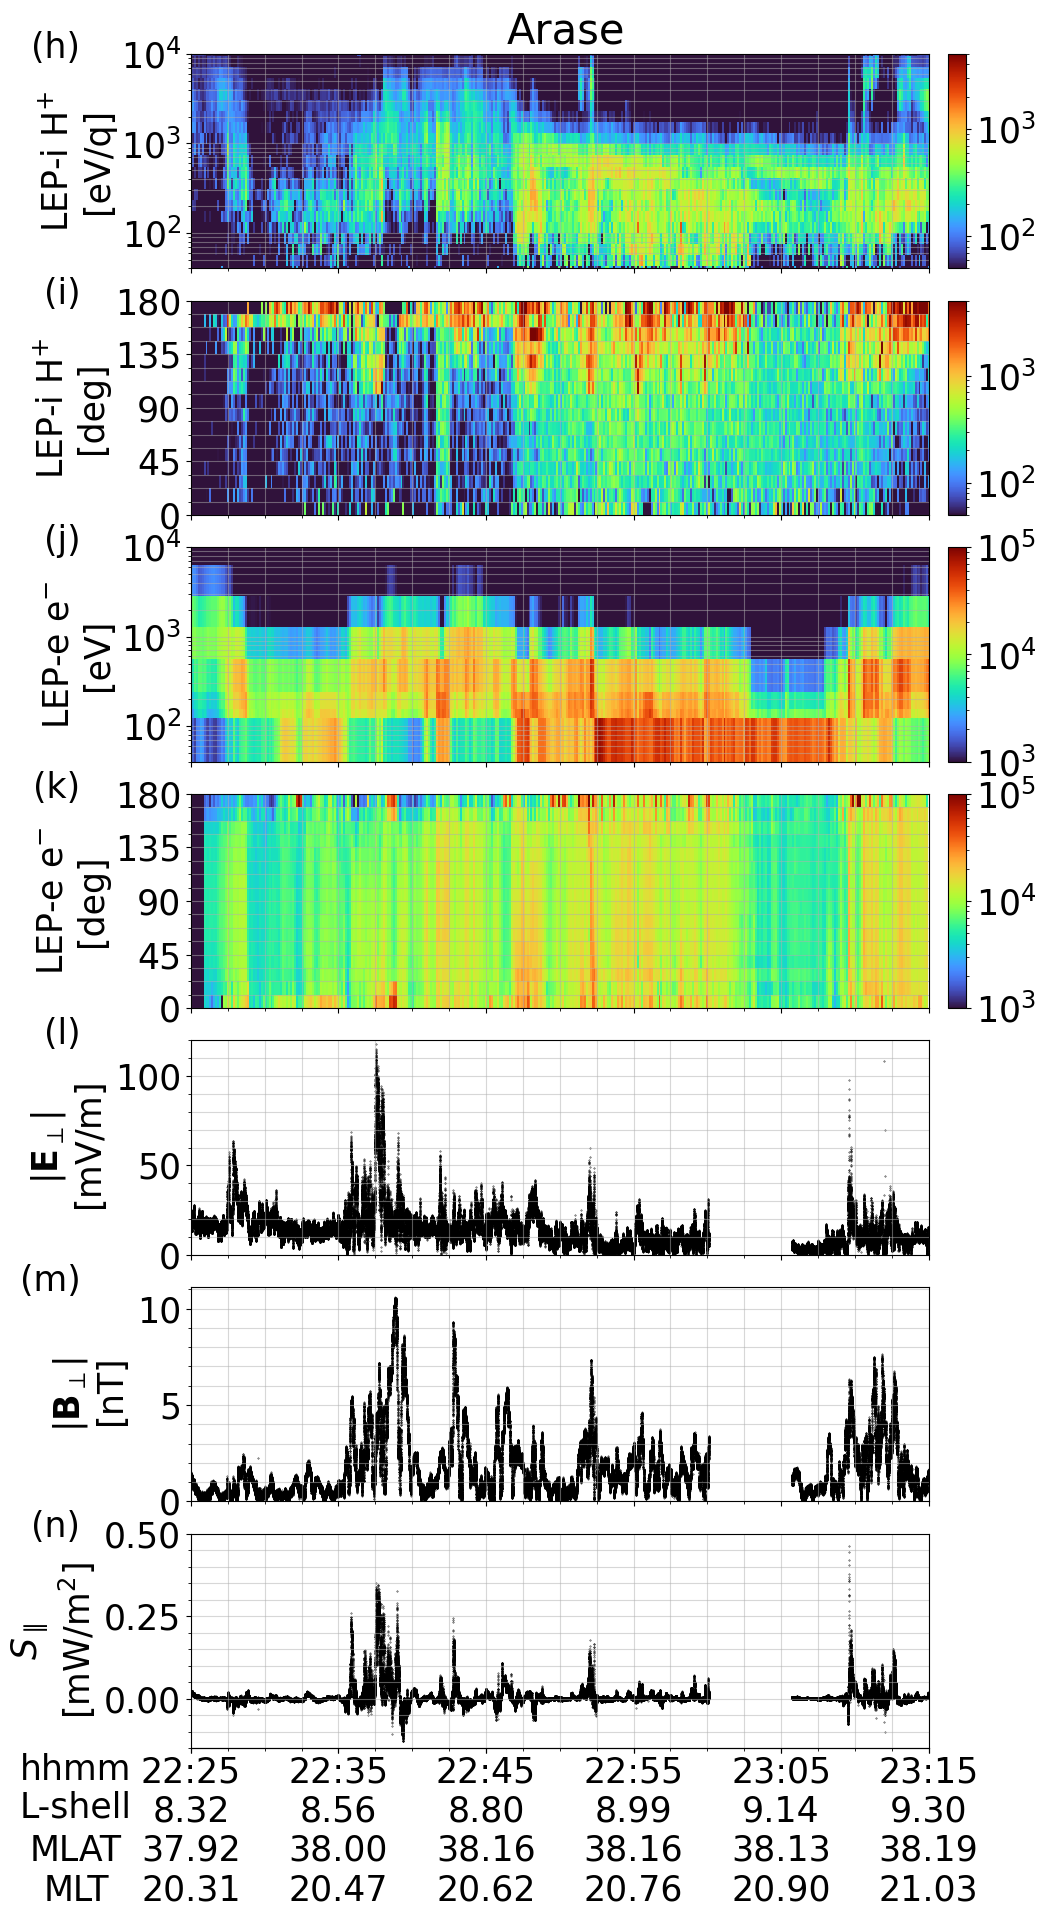

24-Jan-26 22:42:08: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:42:08: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:42:08: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:42:08: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:42:14: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:42:14: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:42:19: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:42:19: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:42:25: /home/satanka/Documents/observation_workspace/.venv_pyspedas/lib/python3.12/site-packages/matplotlib/backends/backend_pdf.py:1761: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgb8, mode='P')

24-Jan-26 22:42:26: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:42:26: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:42:26: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:42:26

In [24]:
import matplotlib.ticker as mticker
from datetime import datetime

mpl.rcParams['font.size'] = 25

fig = plt.figure(figsize=(10, 22))

gs = fig.add_gridspec(7, 2, width_ratios=[1, 0.025], wspace=0.05, hspace=0.15)
ax_1 = fig.add_subplot(gs[0, 0])
cax_1 = fig.add_subplot(gs[0, 1])
ax_2 = fig.add_subplot(gs[1, 0], sharex=ax_1)
cax_2 = fig.add_subplot(gs[1, 1])
ax_3 = fig.add_subplot(gs[2, 0], sharex=ax_1)
cax_3 = fig.add_subplot(gs[2, 1])
ax_4 = fig.add_subplot(gs[3, 0], sharex=ax_1)
cax_4 = fig.add_subplot(gs[3, 1])
ax_5 = fig.add_subplot(gs[4, 0], sharex=ax_1)
ax_6 = fig.add_subplot(gs[5, 0], sharex=ax_1)
ax_7 = fig.add_subplot(gs[6, 0], sharex=ax_1)

ax_1.tick_params(axis='x', which='both', labelbottom=False)
ax_2.tick_params(axis='x', which='both', labelbottom=False)
ax_3.tick_params(axis='x', which='both', labelbottom=False)
ax_4.tick_params(axis='x', which='both', labelbottom=False)
ax_5.tick_params(axis='x', which='both', labelbottom=False)
ax_6.tick_params(axis='x', which='both', labelbottom=False)

ytitle_proton = r'LEP-i $\mathrm{H}^{+}$' + '\n' + r'[eV/q]'
ztitle_proton = r'[$\mathrm{cm}^{-2} \mathrm{sr}^{-1} \mathrm{s}^{-1} \mathrm{eV}^{-1}$]'
omniflux_plot_Arase('lepi', fig, ax_1, cax_1, dq_proton, 5E1, 5E3, 4E1, 1E4, ytitle_proton, ztitle_proton)

ytitle_proton_pa = r'LEP-i $\mathrm{H}^{+}$' + '\n' + r'[deg]'
ztitle_proton_pa = r'[$\mathrm{cm}^{-2} \mathrm{sr}^{-1} \mathrm{s}^{-1} \mathrm{eV}^{-1}$]'
pa_plot_Arase(fig, ax_2, cax_2, dq_proton_pa, 5E1, 5E3, ytitle_proton_pa, ztitle_proton_pa)

ytitle_electron = r'LEP-e $\mathrm{e}^{-}$' + '\n' + r'[eV]'
ztitle_electron = r'[$\mathrm{cm}^{-2} \mathrm{sr}^{-1} \mathrm{s}^{-1} \mathrm{eV}^{-1}$]'
omniflux_plot_Arase('lepe', fig, ax_3, cax_3, dq_electron, 1E3, 1E5, 4E1, 1E4, ytitle_electron, ztitle_electron)

ytitle_electron_pa = r'LEP-e $\mathrm{e}^{-}$' + '\n' + r'[deg]'
ztitle_electron_pa = r'[$\mathrm{cm}^{-2} \mathrm{sr}^{-1} \mathrm{s}^{-1} \mathrm{eV}^{-1}$]'
pa_plot_Arase(fig, ax_4, cax_4, dq_electron_pa, 1E3, 1E5, ytitle_electron_pa, ztitle_electron_pa)

ax_5.scatter(ds_fac.time, np.sqrt(Eperp_2), c='k', s=0.1)
#ax_5.plot(ds_fac.time, np.sqrt(Eperp_2), c='k', linewidth=0.5)
ax_5.set_ylabel(r'$|\mathbf{E}_{\perp}|$' + '\n' + r'[$\mathrm{mV/m}$]')
ax_5.set_ylim(ymin=0, ymax=120)
ax_5.minorticks_on()
ax_5.grid(which='both', alpha=0.5)

ax_6.scatter(ds_fac.time, np.sqrt(Bperp_2), c='k', s=0.1)
#ax_6.plot(ds_fac.time, np.sqrt(Bperp_2), c='k', linewidth=0.5)
ax_6.set_ylabel(r'$|\mathbf{B}_{\perp}|$' + '\n' + r'[$\mathrm{nT}$]')
ax_6.set_ylim(ymin=0)
ax_6.minorticks_on()
ax_6.grid(which='both', alpha=0.5)

ax_7.scatter(ds_fac.time, S_para*1E3, c='k', s=0.1)
#ax_7.plot(ds_fac.time, S_para*1E3, c='k', linewidth=0.5)
ax_7.set_ylabel(r'$S_{\parallel}$' + '\n' + r'[$\mathrm{mW/m^{2}}$]')
ax_7.set_ylim(ymin=-0.15, ymax=0.5)
#ax_7.set_yscale('symlog')
ax_7.minorticks_on()
ax_7.grid(which='both', alpha=0.5)


time_range_analysis     = ['20220901/22:25:00', '20220901/23:15:00']
time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]
to_npdt = lambda s: np.datetime64(datetime.strptime(s, '%Y%m%d/%H:%M:%S'))
time_range_T_analysis_0, time_range_T_analysis_1 = map(to_npdt, time_range_analysis)
ax_7.set_xlim(time_range_T_analysis_0, time_range_T_analysis_1)
ax_7.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax_7.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))

def add_panel_label(ax, label, x=-0.15, y=0.95):
    ax.text(x, y, label, transform=ax.transAxes,
            ha='right', va='bottom', clip_on=False)

def to_py_datetime(t_np64):
    return np.array(t_np64, dtype='datetime64[ms]').astype('datetime64[ms]').astype(object)

# 軌道データ
pos_da = pt.data_quants['erg_orb_l2_pos_rmlatmlt']  # (Nt, 3)
t_pos_py = to_py_datetime(pos_da.time.values)
t_pos_num = mdates.date2num(t_pos_py)               # Matplotlib の日数

R   = np.asarray(pos_da.values[:, 0], dtype=float)  # Re
mlat= np.asarray(pos_da.values[:, 1], dtype=float)  # deg
mlt = np.asarray(pos_da.values[:, 2], dtype=float)  # hour [0,24)

L_shell = R / np.cos(np.deg2rad(mlat))**2E0

# --- MLT の 24h 周期をほどいてから補間し、最後に 24 で折り返す ---
mlt_unwrap = np.unwrap(mlt * 2*np.pi/24.0) * 24.0/(2*np.pi)

# 補間関数（tick の x は「日数」なのでそのまま使う）
def interp_at(x_num):
    #Ri    = np.interp(x_num, t_pos_num, R, left=np.nan, right=np.nan)
    Ri    = np.interp(x_num, t_pos_num, L_shell, left=np.nan, right=np.nan)     # L-shellを示す
    mlati = np.interp(x_num, t_pos_num, mlat, left=np.nan, right=np.nan)
    mltiu = np.interp(x_num, t_pos_num, mlt_unwrap, left=np.nan, right=np.nan)
    mlti  = np.mod(mltiu, 24.0)
    return Ri, mlati, mlti

# 目盛フォーマッタ
def rmlt_formatter(x, pos=None):
    Ri, mlati, mlti = interp_at(x)
    if np.any(~np.isfinite([Ri, mlati, mlti])):
        return ""  # 範囲外は空
    return (f"{Ri:0.2f}\n"
            f"{mlati:0.2f}\n"
            f"{mlti:0.2f}")

# セカンダリ x 軸（底 side）を作ってラベルを差し替え
secax = ax_7.secondary_xaxis('bottom', functions=(lambda x: x, lambda x: x))
secax.xaxis.set_major_formatter(mticker.FuncFormatter(rmlt_formatter))

# メインの時間ラベルと重ならないよう余白を広げる
ax_7.tick_params(axis='x', which='major', pad=2)      # 時間ラベル
secax.tick_params(axis='x', which='major', pad=30)  # R/MLAT/MLTラベル

# 好みで：目盛間隔をメイン x と合わせる
secax.set_ticks(ax_7.get_xticks())

fig.text(0.01, 0.100, "hhmm", ha='center', va='center')
#fig.text(0.01, 0.083, r"R [$R_{\mathrm{E}}$]", ha='center', va='center')
fig.text(0.01, 0.083, r"L-shell", ha='center', va='center')
fig.text(0.01, 0.063, r"MLAT", ha='center', va='center')
fig.text(0.01, 0.045, r"MLT", ha='center', va='center')

add_panel_label(ax_1, '(h)')
add_panel_label(ax_2, '(i)')
add_panel_label(ax_3, '(j)')
add_panel_label(ax_4, '(k)')
add_panel_label(ax_5, '(l)')
add_panel_label(ax_6, '(m)')
add_panel_label(ax_7, '(n)')

fig.suptitle('Arase', y=0.9)

fig.tight_layout()
plt.show()

fig.savefig(r"/mnt/j/KAW_observation/Figure_2_b.pdf", bbox_inches='tight')
fig.savefig(r"/mnt/j/KAW_observation/Figure_2_b.png", bbox_inches='tight')

In [25]:
pos_da_analysis = pos_da.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))

print(np.nanmin(pos_da_analysis[:, 0]), np.nanmax(pos_da_analysis[:, 0]))
print(np.nanmin(pos_da_analysis[:, 1]), np.nanmax(pos_da_analysis[:, 1]))
print(np.nanmin(pos_da_analysis[:, 2]), np.nanmax(pos_da_analysis[:, 2]))


5.1798863 5.746145
37.891216 38.266132
20.308798 21.026745


In [26]:
import pyspedas as psp
import pytplot as pt

time_range = ['20220901/20:00:00', '20220902/00:00:00']
psp.themis.fgm(trange=time_range, probe='a', level='l2', no_update=True, get_support_data=True)                 # fgh: 128 Hz, fgl: 16 Hz, fgs: 2.74 sec
psp.themis.efi(trange=time_range, probe='a', level='l2', datatype='efp', no_update=True, get_support_data=True) # efp: 512 Hz
psp.themis.efi(trange=time_range, probe='a', level='l2', datatype='efi', no_update=True, get_support_data=True) # eff: 8 Hz

E512_data_gsm   = pt.data_quants['tha_efp_gsm']
B16_data_gsm    = pt.data_quants['tha_fgl_gsm']
B128_data_gsm   = pt.data_quants['tha_fgh_gsm']

time_range_T    = [time_range[0].replace('/', 'T'), time_range[1].replace('/', 'T')]
E512_data_gsm   = E512_data_gsm.sortby('time').sel(time=slice(time_range_T[0], time_range_T[1])).dropna(dim='time', how='all')
B16_data_gsm    = B16_data_gsm.sortby('time').sel(time=slice(time_range_T[0], time_range_T[1])).dropna(dim='time', how='all')
B128_data_gsm   = B128_data_gsm.sortby('time').sel(time=slice(time_range_T[0], time_range_T[1])).dropna(dim='time', how='all')

import xarray as xr
import numpy as np

def split_by_gap(ds, time_dim='time', gap_thr=np.timedelta64(30, 's'),
                 prefix='ds_8_gsm_seg'):
    t = ds[time_dim].values
    if t.size == 0:
        return []

    # 先頭はギャップなし。以降で gap_thr を超えたら新セグ開始。
    gaps = np.r_[False, (t[1:] - t[:-1]) > gap_thr]      # shape (Nt,)
    seg_id = np.cumsum(gaps)                              # 0,0,0,1,1,2,...

    ds_tagged = ds.assign_coords(_seg=(time_dim, seg_id))
    segs = [g.drop_vars('_seg') for _, g in ds_tagged.groupby('_seg')]

    return segs

ds_E512_data_gsm = xr.Dataset(
    data_vars={
        "E512_gsm_x": (("time",), E512_data_gsm[:, 0].values),
        "E512_gsm_y": (("time",), E512_data_gsm[:, 1].values),
        "E512_gsm_z": (("time",), E512_data_gsm[:, 2].values),
    },
    coords={
        "time": E512_data_gsm["time"].values,
    },
)
ds_B16_data_gsm = xr.Dataset(
    data_vars={
        "B16_gsm_x": (("time",), B16_data_gsm[:, 0].values),
        "B16_gsm_y": (("time",), B16_data_gsm[:, 1].values),
        "B16_gsm_z": (("time",), B16_data_gsm[:, 2].values),
    },
    coords={
        "time": B16_data_gsm["time"].values,
    },
)
ds_B128_data_gsm = xr.Dataset(
    data_vars={
        "B128_gsm_x": (("time",), B128_data_gsm[:, 0].values),
        "B128_gsm_y": (("time",), B128_data_gsm[:, 1].values),
        "B128_gsm_z": (("time",), B128_data_gsm[:, 2].values),
    },
    coords={
        "time": B128_data_gsm["time"].values,
    },
)

def uniq_and_sort_time(ds):
    idx = ds.get_index('time')
    mask = ~idx.duplicated()          # 最初の出現だけ True
    return ds.isel(time=mask).sortby('time')

ds_E512_data_gsm    = uniq_and_sort_time(ds_E512_data_gsm)
ds_B16_data_gsm     = uniq_and_sort_time(ds_B16_data_gsm)
ds_B128_data_gsm    = uniq_and_sort_time(ds_B128_data_gsm)

ds_E512_data_gsm_segs = split_by_gap(ds_E512_data_gsm, gap_thr=np.timedelta64(8, 'ms'))
for ds_ in ds_E512_data_gsm_segs:
    print(ds_.time)

ds_B16_data_gsm_segs = split_by_gap(ds_B16_data_gsm, gap_thr=np.timedelta64(250, 'ms'))
for ds_ in ds_B16_data_gsm_segs:
    print(ds_.time)

ds_B128_data_gsm_segs = split_by_gap(ds_B128_data_gsm, gap_thr=np.timedelta64(250, 'ms'))
for ds_ in ds_B128_data_gsm_segs:
    print(ds_.time)

def make_ds_EB_func(ds_E, E_vars, ds_B, B_vars, time_base, output_vars):
    ds_E_interp = ds_E.interp(time=time_base, method='linear')
    ds_B_interp = ds_B.interp(time=time_base, method='linear')

    da_Ex   = ds_E_interp[E_vars[0]]
    da_Ey   = ds_E_interp[E_vars[1]]
    da_Ez   = ds_E_interp[E_vars[2]]
    da_Bx   = ds_B_interp[B_vars[0]]
    da_By   = ds_B_interp[B_vars[1]]
    da_Bz   = ds_B_interp[B_vars[2]]

    ds_EB   = xr.Dataset({
        output_vars[0]: da_Ex,
        output_vars[1]: da_Ey,
        output_vars[2]: da_Ez,
        output_vars[3]: da_Bx,
        output_vars[4]: da_By,
        output_vars[5]: da_Bz,
    })

    ds_EB   = ds_EB.dropna(dim='time', how='any')

    return ds_EB

E512_vars   = ['E512_gsm_x', 'E512_gsm_y', 'E512_gsm_z']
B16_vars    = ['B16_gsm_x', 'B16_gsm_y', 'B16_gsm_z']
B128_vars   = ['B128_gsm_x', 'B128_gsm_y', 'B128_gsm_z']
EB128_vars  = ['E128_gsm_x', 'E128_gsm_y', 'E128_gsm_z', 'B128_gsm_x', 'B128_gsm_y', 'B128_gsm_z']

ds_EB128_gsm_segs = []

ds_EB128_gsm_segs.append(make_ds_EB_func(ds_E512_data_gsm_segs[0], E512_vars, ds_B128_data_gsm_segs[0], B128_vars, ds_B128_data_gsm_segs[0].time, EB128_vars).dropna(dim='time', how='all'))
ds_EB128_gsm_segs.append(make_ds_EB_func(ds_E512_data_gsm_segs[1], E512_vars, ds_B128_data_gsm_segs[1], B128_vars, ds_B128_data_gsm_segs[1].time, EB128_vars).dropna(dim='time', how='all'))
ds_EB128_gsm_segs.append(make_ds_EB_func(ds_E512_data_gsm_segs[2], E512_vars, ds_B128_data_gsm_segs[2], B128_vars, ds_B128_data_gsm_segs[2].time, EB128_vars).dropna(dim='time', how='all'))

psp.themis.state(probe='a', trange=time_range, no_update=True)

da_THA_pos_gsm  = pt.data_quants['tha_pos_gsm']
da_THA_pos_gsm  = da_THA_pos_gsm.sortby('time').sel(time=slice(time_range[0], time_range[1]))

da_THA_pos_unit_gsm = da_THA_pos_gsm / np.sqrt((da_THA_pos_gsm * da_THA_pos_gsm).sum(dim='v_dim'))

background_time_sec = 100 #[sec]

time_width_B_16Hz       = (B16_data_gsm.time[10] - B16_data_gsm.time[9]) / np.timedelta64(1, 's')
da_B_background         = B16_data_gsm.rolling(time=int(background_time_sec/time_width_B_16Hz), center=True).mean('time')
da_B_background_unit    = da_B_background / np.sqrt((da_B_background * da_B_background).sum(dim='v_dim'))
da_B_background_unit    = da_B_background_unit.dropna(how='all', dim='time')

time_array  = da_B_background_unit.time

da_THA_pos_unit_gsm_interp    = da_THA_pos_unit_gsm.interp(time=time_array)

da_u_   = da_THA_pos_unit_gsm_interp - (da_THA_pos_unit_gsm_interp * da_B_background_unit).sum(dim='v_dim') * da_B_background_unit

da_e_z_FAC_inGSM    = da_B_background_unit.drop_attrs()
da_e_x_FAC_inGSM    = (da_u_ / np.sqrt((da_u_ * da_u_).sum(dim='v_dim'))).drop_attrs()
da_e_y_FAC_inGSM    = (xr.apply_ufunc(np.cross, da_e_z_FAC_inGSM, da_e_x_FAC_inGSM, input_core_dims=[['v_dim'], ['v_dim']], output_core_dims=[['v_dim']], vectorize=True)).drop_attrs()

R_FAC_to_GSM = xr.concat(
    [da_e_x_FAC_inGSM, da_e_y_FAC_inGSM, da_e_z_FAC_inGSM],
    dim='axis'
)
R_FAC_to_GSM    = R_FAC_to_GSM.assign_coords(axis=['x_FAC', 'y_FAC', 'z_FAC']).assign_coords(v_dim=np.arange(3))
R_FAC_to_GSM    = R_FAC_to_GSM.dropna(dim='time', how='any')

R_GSM_to_FAC    = R_FAC_to_GSM.transpose('time', 'v_dim', 'axis')

da_e_x_GSM_inFAC    = R_GSM_to_FAC.sel(v_dim=0)
da_e_y_GSM_inFAC    = R_GSM_to_FAC.sel(v_dim=1)
da_e_z_GSM_inFAC    = R_GSM_to_FAC.sel(v_dim=2)

ds_EB128_fac_segs = []

for ds_seg in ds_EB128_gsm_segs:
    # 1) この seg の時間に合わせて回転行列を補間
    R_seg = R_GSM_to_FAC.interp(time=ds_seg.time)

    # 2) DSIベクトル (time, v_dim) を作る
    E_dsi = xr.concat(
        [ds_seg['E128_gsm_x'], ds_seg['E128_gsm_y'], ds_seg['E128_gsm_z']],
        dim='v_dim'
    )
    B_dsi = xr.concat(
        [ds_seg['B128_gsm_x'], ds_seg['B128_gsm_y'], ds_seg['B128_gsm_z']],
        dim='v_dim'
    )

    # こちらも v_dim を 0,1,2 にそろえる
    E_dsi = E_dsi.assign_coords(v_dim=np.arange(3))
    B_dsi = B_dsi.assign_coords(v_dim=np.arange(3))

    # 3) DSI → FAC 回転
    E_fac = xr.dot(E_dsi, R_seg, dims='v_dim')  # (time, axis)
    B_fac = xr.dot(B_dsi, R_seg, dims='v_dim')

    # 4) axis 次元を変数に落とす
    E_fac_ds = (
        E_fac
        .to_dataset(dim='axis')
        .rename({
            'x_FAC': 'E128_fac_x',
            'y_FAC': 'E128_fac_y',
            'z_FAC': 'E128_fac_z',
        })
    )

    B_fac_ds = (
        B_fac
        .to_dataset(dim='axis')
        .rename({
            'x_FAC': 'B128_fac_x',
            'y_FAC': 'B128_fac_y',
            'z_FAC': 'B128_fac_z',
        })
    )

    ds_fac = xr.merge([E_fac_ds, B_fac_ds]).dropna(dim='time', how='any')
    ds_fac = ds_fac.assign_attrs(ds_seg.attrs)
    ds_EB128_fac_segs.append(ds_fac)

24-Jan-26 22:42:48: Local file found: /mnt/j/observation_data//themis/tha/l2/fgm/2022/tha_l2_fgm_20220901_v01.cdf


24-Jan-26 22:42:57: Local file found: /mnt/j/observation_data//themis/tha/l2/efp/2022/tha_l2_efp_20220901_v01.cdf
24-Jan-26 22:43:00: Variable tha_efp_time is marked as record-varying, but no DEPEND_TIME or DEPEND_0 attributes found. Treating as non-record-varying.
24-Jan-26 22:43:01: Local file found: /mnt/j/observation_data//themis/tha/l2/efi/2022/tha_l2_efi_20220901_v01.cdf
24-Jan-26 22:43:01: Variable tha_efs_dot0_time is marked as record-varying, but no DEPEND_TIME or DEPEND_0 attributes found. Treating as non-record-varying.
24-Jan-26 22:43:01: Variable tha_efs_q_mag_time is marked as record-varying, but no DEPEND_TIME or DEPEND_0 attributes found. Treating as non-record-varying.
24-Jan-26 22:43:01: Variable tha_efs_q_pha_time is marked as record-varying, but no DEPEND_TIME or DEPEND_0 attributes found. Treating as non-record-varying.
24-Jan-26 22:43:03: Variable tha_eff_dot0_time is marked as record-varying, but no DEPEND_TIME or DEPEND_0 attributes found. Treating as non-record

<xarray.DataArray 'time' (time: 175616)> Size: 1MB
array(['2022-09-01T22:28:46.326751744', '2022-09-01T22:28:46.328704768',
       '2022-09-01T22:28:46.330658048', ..., '2022-09-01T22:34:29.320892416',
       '2022-09-01T22:34:29.322845440', '2022-09-01T22:34:29.324798464'],
      shape=(175616,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 1MB 2022-09-01T22:28:46.326751744 ... 2022...
<xarray.DataArray 'time' (time: 351744)> Size: 3MB
array(['2022-09-01T22:45:58.326766848', '2022-09-01T22:45:58.328720128',
       '2022-09-01T22:45:58.330673152', ..., '2022-09-01T22:57:25.320907520',
       '2022-09-01T22:57:25.322860800', '2022-09-01T22:57:25.324813824'],
      shape=(351744,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 3MB 2022-09-01T22:45:58.326766848 ... 2022...
<xarray.DataArray 'time' (time: 176128)> Size: 1MB
array(['2022-09-01T23:03:45.326751744', '2022-09-01T23:03:45.328704768',
       '2022-09-01T23:03:45.330658048', ..

24-Jan-26 22:43:08: Local file found: /mnt/j/observation_data//themis/tha/l1/state/2022/tha_l1_state_20220901.cdf
24-Jan-26 22:43:26: /tmp/ipykernel_30032/1653159965.py:181: PendingDeprecationWarning: The `dims` argument has been renamed to `dim`, and will be removed in the future. This renaming is taking place throughout xarray over the next few releases.
  E_fac = xr.dot(E_dsi, R_seg, dims='v_dim')  # (time, axis)

24-Jan-26 22:43:26: /tmp/ipykernel_30032/1653159965.py:182: PendingDeprecationWarning: The `dims` argument has been renamed to `dim`, and will be removed in the future. This renaming is taking place throughout xarray over the next few releases.
  B_fac = xr.dot(B_dsi, R_seg, dims='v_dim')

24-Jan-26 22:43:26: /tmp/ipykernel_30032/1653159965.py:181: PendingDeprecationWarning: The `dims` argument has been renamed to `dim`, and will be removed in the future. This renaming is taking place throughout xarray over the next few releases.
  E_fac = xr.dot(E_dsi, R_seg, dims='v_dim'

In [27]:
Ex_fac_vec = xr.concat([ds_EB128_fac_segs[0]['E128_fac_x'], ds_EB128_fac_segs[1]['E128_fac_x'], ds_EB128_fac_segs[2]['E128_fac_x']], dim='time')
Ey_fac_vec = xr.concat([ds_EB128_fac_segs[0]['E128_fac_y'], ds_EB128_fac_segs[1]['E128_fac_y'], ds_EB128_fac_segs[2]['E128_fac_y']], dim='time')
Bx_fac_vec = xr.concat([ds_EB128_fac_segs[0]['B128_fac_x'], ds_EB128_fac_segs[1]['B128_fac_x'], ds_EB128_fac_segs[2]['B128_fac_x']], dim='time')
By_fac_vec = xr.concat([ds_EB128_fac_segs[0]['B128_fac_y'], ds_EB128_fac_segs[1]['B128_fac_y'], ds_EB128_fac_segs[2]['B128_fac_y']], dim='time')

In [28]:
Eperp_2_THA = ((Ex_fac_vec)**2E0 + (Ey_fac_vec)**2E0)
Bperp_2_THA = ((Bx_fac_vec)**2E0 + (By_fac_vec)**2E0)

mu_0 = 4.*np.pi * 1E-7

S_para_THA = (Ex_fac_vec * By_fac_vec - Ey_fac_vec * Bx_fac_vec) / mu_0 * 1E-12 #W/m^2

print(Eperp_2_THA)
print(Bperp_2_THA)
print(S_para_THA)

<xarray.DataArray (time: 173794)> Size: 1MB
array([29.53124699, 31.0675382 , 33.30914986, ..., 21.52277601,
       20.48217344, 22.21393516], shape=(173794,))
Coordinates:
  * time     (time) datetime64[ns] 1MB 2022-09-01T22:28:51.404449536 ... 2022...
<xarray.DataArray (time: 173794)> Size: 1MB
array([0.55497095, 0.20171221, 0.8008996 , ..., 5.70390737, 6.38416827,
       6.43969816], shape=(173794,))
Coordinates:
  * time     (time) datetime64[ns] 1MB 2022-09-01T22:28:51.404449536 ... 2022...
<xarray.DataArray (time: 173794)> Size: 1MB
array([ 2.73999370e-06,  1.75142603e-06,  3.66140601e-06, ...,
       -5.04774443e-06, -4.19947870e-06, -5.14946443e-06], shape=(173794,))
Coordinates:
  * time     (time) datetime64[ns] 1MB 2022-09-01T22:28:51.404449536 ... 2022...


In [29]:
psp.themis.state(trange=trange, probe='a', no_update=True)

24-Jan-26 22:43:27: Local file found: /mnt/j/observation_data//themis/tha/l1/state/2022/tha_l1_state_20220901.cdf


['tha_pos',
 'tha_vel',
 'tha_spin_initial_delta_phi',
 'tha_spin_idpu_spinper',
 'tha_spin_segflags',
 'tha_spin_ecl_initial_delta_phi',
 'tha_spin_ecl_idpu_spinper',
 'tha_spin_ecl_segflags',
 'tha_pos_gse',
 'tha_pos_gsm',
 'tha_vel_gse',
 'tha_vel_gsm',
 'tha_pos_sel',
 'tha_pos_sse',
 'tha_vel_sel',
 'tha_vel_sse']

In [30]:
psp.cotrans(name_in='tha_pos_gsm', name_out='tha_pos_sm', coord_in='gsm', coord_out='sm')
THA_SM_pos = pt.data_quants['tha_pos_sm'].sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
print(THA_SM_pos)

THA_rmlatmlt_R = np.sqrt(THA_SM_pos.data[:, 0]**2E0 + THA_SM_pos.data[:, 1]**2E0 + THA_SM_pos.data[:, 2]**2E0) / 6378.1
THA_rmlatmlt_MLAT = np.rad2deg(np.arctan2(THA_SM_pos.data[:, 2], np.sqrt(THA_SM_pos.data[:, 0]**2E0 + THA_SM_pos.data[:, 1]**2E0)))
THA_rmlatmlt_MLT = np.rad2deg(np.arctan2(THA_SM_pos.data[:, 1], THA_SM_pos.data[:, 0])) / 15. + 12.

THA_rmlatmlt_L  = THA_rmlatmlt_R / np.cos(np.deg2rad(THA_rmlatmlt_MLAT))**2E0

print(np.nanmax(THA_rmlatmlt_R), np.nanmin(THA_rmlatmlt_R))
print(np.nanmax(THA_rmlatmlt_MLAT), np.nanmin(THA_rmlatmlt_MLAT))
print(np.nanmax(THA_rmlatmlt_MLT), np.nanmin(THA_rmlatmlt_MLT))

print(np.nanmax(THA_rmlatmlt_L), np.nanmin(THA_rmlatmlt_L))

24-Jan-26 22:44:18: ['gsm', 'sm']
24-Jan-26 22:44:18: Running transformation: subgsm2sm
24-Jan-26 22:44:18: Setting coordinate system for tha_pos_sm
24-Jan-26 22:44:18: Output variable: tha_pos_sm


<xarray.DataArray 'tha_pos_sm' (time: 51, v_dim: 3)> Size: 1kB
array([[-45221.02819604,  25284.55859375,  -2049.96197608],
       [-45377.35354117,  25274.12304688,  -2016.58554071],
       [-45533.19485582,  25263.4375    ,  -1983.0360044 ],
       [-45688.52777096,  25252.50390625,  -1949.3179977 ],
       [-45843.36787637,  25241.33984375,  -1915.43351402],
       [-45997.71487732,  25229.9453125 ,  -1881.38502905],
       [-46151.56536315,  25218.30859375,  -1847.16960955],
       [-46304.92705676,  25206.43945312,  -1812.78900311],
       [-46457.79485302,  25194.34960938,  -1778.25139192],
       [-46610.18086876,  25182.03320312,  -1743.55572716],
       [-46762.07367653,  25169.49414062,  -1708.69986384],
       [-46913.48393742,  25156.74023438,  -1673.69240872],
       [-47064.40882234,  25143.75585938,  -1638.52660547],
       [-47214.86372872,  25130.54296875,  -1603.20582118],
       [-47364.82449167,  25117.125     ,  -1567.73396946],
       [-47514.3263469 ,  25103.48046

[[ 445.56836731  246.98194063  118.25597871  132.4819722   138.89750878
   214.56450718  300.80194921  481.14456262]
 [ 319.20343757  398.70740512  365.57419504  494.81574678  534.43045965
   648.29848187  656.31575705  617.72879675]
 [ 263.41927625  189.72121164  217.97703721  210.4995486   169.11437763
   173.39030275  156.06676433  301.85479196]
 [1093.54010701  445.55350996  280.37464395  280.33602473  290.9966498
   393.9216191   605.66310498 1052.65163149]
 [ 172.35605829  189.86423376  169.0196023   173.62502684  166.79165794
   172.39952771  156.54757676  165.68012322]
 [ 101.78177444  152.14377545  137.069198     96.63664084  101.63083568
    90.70469569  121.0956128   241.33608203]
 [ 165.52405713  137.7608755   154.42372771  164.05895334  228.98813185
   192.67297448  211.29145142  241.03451905]
 [ 208.97455296  193.96973224  159.71876719  173.65177572  154.80144747
   185.19934734  168.61015493  244.74624591]
 [ 201.19943988  154.40668772  180.83379518  149.40053247  159.31

[[1.00000000e-99 1.00000000e-99 1.00000000e-99 ... 1.00000000e-99
  1.00000000e-99 1.00000000e-99]
 [5.30244962e+03 2.43980856e+03 1.08608014e+03 ... 1.23450812e+03
  2.94551221e+03 6.09059799e+03]
 [4.29444303e+03 2.23736375e+03 1.02910970e+03 ... 1.08058472e+03
  2.10996807e+03 4.73333183e+03]
 ...
 [6.97316237e+03 5.23173230e+03 5.03756213e+03 ... 5.08734007e+03
  5.56592097e+03 7.13261806e+03]
 [6.74790196e+03 5.38056981e+03 5.00713836e+03 ... 5.17439142e+03
  5.65678355e+03 7.03555153e+03]
 [6.72449696e+03 5.39350530e+03 4.96789269e+03 ... 4.97043126e+03
  5.68426201e+03 7.16670923e+03]]
(1090,)


24-Jan-26 22:45:53: /tmp/ipykernel_30032/3698870457.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()

24-Jan-26 22:46:16: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:46:16: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:46:16: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:46:16: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:46:17: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:46:17: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:46:18: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:46:18: Substituting symbol \perp from STIXGeneral


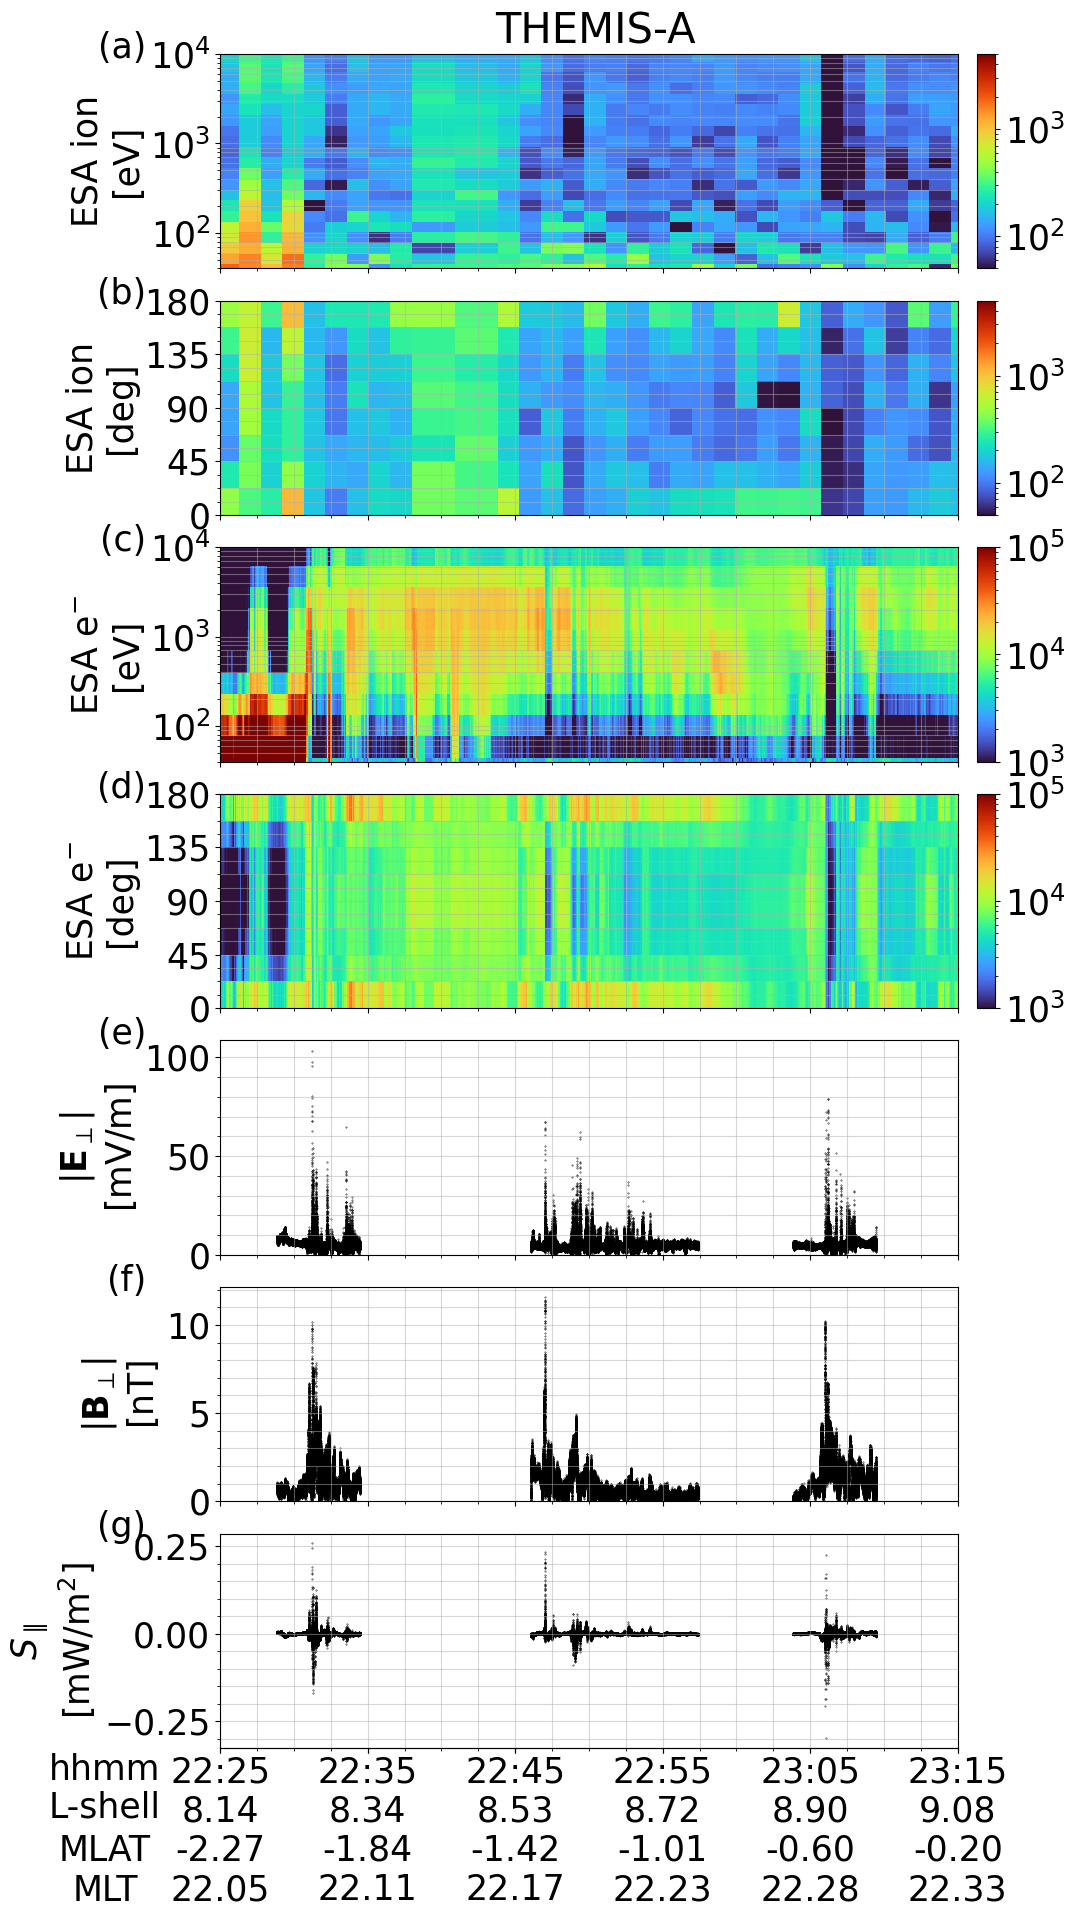

24-Jan-26 22:46:21: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:46:21: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:46:21: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:46:21: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:46:31: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:46:31: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:46:35: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:46:35: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:46:39: /home/satanka/Documents/observation_workspace/.venv_pyspedas/lib/python3.12/site-packages/matplotlib/backends/backend_pdf.py:1761: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgb8, mode='P')

24-Jan-26 22:46:40: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:46:40: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:46:40: Substituting symbol \perp from STIXGeneral
24-Jan-26 22:46:40

In [31]:
import matplotlib.ticker as mticker

fig = plt.figure(figsize=(10, 22))
gs = fig.add_gridspec(7, 2, width_ratios=[1, 0.025], wspace=0.05, hspace=0.15)
ax_1 = fig.add_subplot(gs[0, 0])
cax_1 = fig.add_subplot(gs[0, 1])
ax_2 = fig.add_subplot(gs[1, 0], sharex=ax_1)
cax_2 = fig.add_subplot(gs[1, 1])
ax_3 = fig.add_subplot(gs[2, 0], sharex=ax_1)
cax_3 = fig.add_subplot(gs[2, 1])
ax_4 = fig.add_subplot(gs[3, 0], sharex=ax_1)
cax_4 = fig.add_subplot(gs[3, 1])
ax_5 = fig.add_subplot(gs[4, 0], sharex=ax_1)
ax_6 = fig.add_subplot(gs[5, 0], sharex=ax_1)
ax_7 = fig.add_subplot(gs[6, 0], sharex=ax_1)

ax_1.tick_params(axis='x', which='both', labelbottom=False)
ax_2.tick_params(axis='x', which='both', labelbottom=False)
ax_3.tick_params(axis='x', which='both', labelbottom=False)
ax_4.tick_params(axis='x', which='both', labelbottom=False)
ax_5.tick_params(axis='x', which='both', labelbottom=False)
ax_6.tick_params(axis='x', which='both', labelbottom=False)

ytitle_proton = r'ESA ion' + '\n' + r'[eV]'
ztitle_proton = r'[$\mathrm{cm}^{-2} \mathrm{sr}^{-1} \mathrm{s}^{-1} \mathrm{eV}^{-1}$]'
omniflux_plot_THEMIS_A(fig, ax_1, cax_1, dn_tha_proton, 5E1, 5E3, 4E1, 1E4, ytitle_proton, ztitle_proton)

ytitle_proton_pa = r'ESA ion' + '\n' + r'[deg]'
ztitle_proton_pa = r'[$\mathrm{cm}^{-2} \mathrm{sr}^{-1} \mathrm{s}^{-1} \mathrm{eV}^{-1}$]'
pa_plot_THEMIS_A(fig, ax_2, cax_2, da_tha_proton_pa, 5E1, 5E3, ytitle_proton_pa, ztitle_proton_pa)

ytitle_electron = r'ESA $\mathrm{e}^{-}$' + '\n' + r'[eV]'
ztitle_electron = r'[$\mathrm{cm}^{-2} \mathrm{sr}^{-1} \mathrm{s}^{-1} \mathrm{eV}^{-1}$]'
omniflux_plot_THEMIS_A(fig, ax_3, cax_3, dn_tha_electron, 1E3, 1E5, 4E1, 1E4, ytitle_electron, ztitle_electron)

ytitle_electron_pa = r'ESA $\mathrm{e}^{-}$' + '\n' + r'[deg]'
ztitle_electron_pa = r'[$\mathrm{cm}^{-2} \mathrm{sr}^{-1} \mathrm{s}^{-1} \mathrm{eV}^{-1}$]'
pa_plot_THEMIS_A(fig, ax_4, cax_4, da_tha_electron_pa, 1E3, 1E5, ytitle_electron_pa, ztitle_electron_pa)

ax_5.scatter(Eperp_2_THA.time, np.sqrt(Eperp_2_THA.data), c='k', s=0.1)
#ax_5.plot(Ex_fac_vec.time, Eperp_2_THA, c='k', linewidth=0.5)
ax_5.set_ylabel(r'$|\mathbf{E}_{\perp}|$' + '\n' + r'[$\mathrm{mV/m}$]')
ax_5.set_ylim(ymin=0)#, ymax=4)
ax_5.minorticks_on()
ax_5.grid(which='both', alpha=0.5)

ax_6.scatter(Bperp_2_THA.time, np.sqrt(Bperp_2_THA.data), c='k', s=0.1)
#ax_6.plot(Ex_fac_vec.time, Bperp_2_THA, c='k', linewidth=0.5)
ax_6.set_ylabel(r'$|\mathbf{B}_{\perp}|$' + '\n' + r'[$\mathrm{nT}$]')
ax_6.set_ylim(ymin=0)
ax_6.minorticks_on()
ax_6.grid(which='both', alpha=0.5)


ax_7.scatter(S_para_THA.time, S_para_THA.data*1E3, c='k', s=0.1)
#ax_7.plot(Ex_fac_vec.time, S_para_THA*1E3, c='k', linewidth=0.5)
ax_7.set_ylabel(r'$S_{\parallel}$' + '\n' + r'[$\mathrm{mW/m^{2}}$]')
#ax_7.set_yscale('symlog')
ax_7.minorticks_on()
ax_7.grid(which='both', alpha=0.5)


time_range_analysis     = ['20220901/22:25:00', '20220901/23:15:00']
time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]
to_npdt = lambda s: np.datetime64(datetime.strptime(s, '%Y%m%d/%H:%M:%S'))
time_range_T_analysis_0, time_range_T_analysis_1 = map(to_npdt, time_range_analysis)
ax_7.set_xlim(time_range_T_analysis_0, time_range_T_analysis_1)
ax_7.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax_7.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))

def add_panel_label(ax, label, x=-0.10, y=0.95):
    ax.text(x, y, label, transform=ax.transAxes,
            ha='right', va='bottom', clip_on=False)

def to_py_datetime(t_np64):
    return np.array(t_np64, dtype='datetime64[ms]').astype('datetime64[ms]').astype(object)

# 軌道データ
t_pos_py = to_py_datetime(THA_SM_pos.time.values)
t_pos_num = mdates.date2num(t_pos_py)               # Matplotlib の日数

R   = np.asarray(THA_rmlatmlt_R, dtype=float)  # Re
mlat= np.asarray(THA_rmlatmlt_MLAT, dtype=float)  # deg
mlt = np.asarray(THA_rmlatmlt_MLT, dtype=float)  # hour [0,24)

L_shell = np.asarray(THA_rmlatmlt_L, dtype=float)

# --- MLT の 24h 周期をほどいてから補間し、最後に 24 で折り返す ---
mlt_unwrap = np.unwrap(mlt * 2*np.pi/24.0) * 24.0/(2*np.pi)

# 補間関数（tick の x は「日数」なのでそのまま使う）
def interp_at(x_num):
    #Ri    = np.interp(x_num, t_pos_num, R, left=np.nan, right=np.nan)
    Ri    = np.interp(x_num, t_pos_num, L_shell, left=np.nan, right=np.nan)   # L-shell
    mlati = np.interp(x_num, t_pos_num, mlat, left=np.nan, right=np.nan)
    mltiu = np.interp(x_num, t_pos_num, mlt_unwrap, left=np.nan, right=np.nan)
    mlti  = np.mod(mltiu, 24.0)
    return Ri, mlati, mlti

# 目盛フォーマッタ
def rmlt_formatter(x, pos=None):
    Ri, mlati, mlti = interp_at(x)
    if np.any(~np.isfinite([Ri, mlati, mlti])):
        return ""  # 範囲外は空
    return (f"{Ri:0.2f}\n"
            f"{mlati:0.2f}\n"
            f"{mlti:0.2f}")

# セカンダリ x 軸（底 side）を作ってラベルを差し替え
secax = ax_7.secondary_xaxis('bottom', functions=(lambda x: x, lambda x: x))
secax.xaxis.set_major_formatter(mticker.FuncFormatter(rmlt_formatter))

# メインの時間ラベルと重ならないよう余白を広げる
ax_7.tick_params(axis='x', which='major', pad=2)      # 時間ラベル
secax.tick_params(axis='x', which='major', pad=30)  # R/MLAT/MLTラベル

# 好みで：目盛間隔をメイン x と合わせる
secax.set_ticks(ax_7.get_xticks())

fig.text(0.01, 0.100, "hhmm", ha='center', va='center')
#fig.text(0.01, 0.083, r"R [$R_{\mathrm{E}}$]", ha='center', va='center')
fig.text(0.01, 0.083, r"L-shell", ha='center', va='center')
fig.text(0.01, 0.063, r"MLAT", ha='center', va='center')
fig.text(0.01, 0.045, r"MLT", ha='center', va='center')

add_panel_label(ax_1, '(a)')
add_panel_label(ax_2, '(b)')
add_panel_label(ax_3, '(c)')
add_panel_label(ax_4, '(d)')
add_panel_label(ax_5, '(e)')
add_panel_label(ax_6, '(f)')
add_panel_label(ax_7, '(g)')

fig.suptitle('THEMIS-A', y=0.9)

plt.tight_layout()
plt.show()

fig.savefig(r"/mnt/j/KAW_observation/Figure_2_a.pdf", bbox_inches='tight')
fig.savefig(r"/mnt/j/KAW_observation/Figure_2_a.png", bbox_inches='tight')

# SYM-H index, AE indexのplot

In [43]:
psp.omni.data(trange=time_range, no_update=True)
print(pt.tplot_names())

22-Jan-26 14:06:54: Local files found: ['/mnt/j/observation_data//omni/hro_1min/2022/omni_hro_1min_20220901_v01.cdf']


0 : erg_lepe_l2_3dflux_FEDU
1 : erg_lepe_l2_omniflux_FEDO
2 : erg_lepi_l2_3dflux_Epoch
3 : erg_lepi_l2_3dflux_FPDU
4 : erg_lepi_l2_3dflux_FPDU_sub
5 : erg_lepi_l2_3dflux_FPEDU
6 : erg_lepi_l2_3dflux_FPEDU_sub
7 : erg_lepi_l2_3dflux_FPDU_COUNT_RAW
8 : erg_lepi_l2_3dflux_FPDU_COUNT_RAW_sub
9 : erg_lepi_l2_3dflux_FPDU_Quality
10 : erg_lepi_l2_3dflux_FHEDU
11 : erg_lepi_l2_3dflux_FHEDU_sub
12 : erg_lepi_l2_3dflux_FHEEDU
13 : erg_lepi_l2_3dflux_FHEEDU_sub
14 : erg_lepi_l2_3dflux_FHEDU_COUNT_RAW
15 : erg_lepi_l2_3dflux_FHEDU_COUNT_RAW_sub
16 : erg_lepi_l2_3dflux_FHEDU_Quality
17 : erg_lepi_l2_3dflux_FODU
18 : erg_lepi_l2_3dflux_FODU_sub
19 : erg_lepi_l2_3dflux_FOEDU
20 : erg_lepi_l2_3dflux_FOEDU_sub
21 : erg_lepi_l2_3dflux_FODU_COUNT_RAW
22 : erg_lepi_l2_3dflux_FODU_COUNT_RAW_sub
23 : erg_lepi_l2_3dflux_FODU_Quality
24 : erg_lepi_l2_3dflux_FPDU_raw
25 : erg_lepi_l2_3dflux_FPDU_sub_raw
26 : erg_lepi_l2_3dflux_FHEDU_raw
27 : erg_lepi_l2_3dflux_FHEDU_sub_raw
28 : erg_lepi_l2_3dflux_FODU_raw
29 

In [44]:
da_sym_h    = pt.data_quants['SYM_H']
da_ae_index = pt.data_quants['AE_INDEX']
da_au_index = pt.data_quants['AU_INDEX']
da_al_index = pt.data_quants['AL_INDEX']

print(da_sym_h)
print(da_ae_index)
print(da_au_index)
print(da_al_index)

<xarray.DataArray 'SYM_H' (time: 241)> Size: 964B
array([-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -2, -1, -1, -1, -1, -1, -1,  0, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -2, -1, -2, -2, -2, -2, -2, -2, -2, -2, -2,
       -2, -2, -2, -2, -2, -2, -2, -2, -2, -3, -3, -3, -3, -3, -3, -3, -3,
       -4, -4, -4, -4, -4, -4, -4, -3, -3, -3, -3, -3, -3, -3, -3, -3, -4,
       -4, -4, -4, -4, -4, -4, -4, -4, -4, -4, -3, -4, -4, -4, -4, -4, -4,
       -4, -4, -5, -4, -4, -5, -5, -5, -5, -5, -5, -4, -4, -5, -4, -5, -5,
       -4, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -4, -5,
       -4, -4, -5, -4, -4, -4, -4, -4, -4, -4, -4, -4, -4, -4, -4, -4, -4,
       -4, -4, -4, -3, -3, -3, -2, -2, -2, -2, -2, -2, -1, -1, -1, -2, -2,
       -2, -2, -2, -2, -2, -2, -1, -2, -1, -1, -1, -1, -1, -1,  0, -1,  0,
       -1, -1, -1, -1, -1, -1,  0,  0,  0,  0,  0,

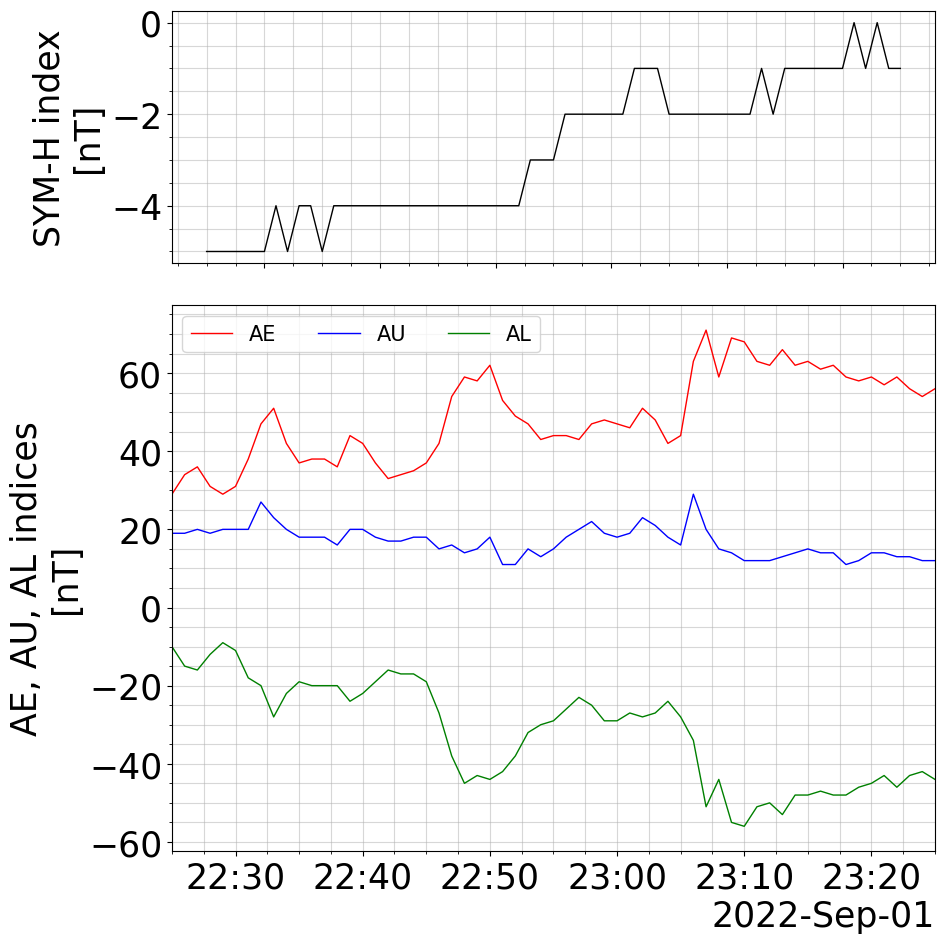

In [45]:
from datetime import datetime

time_range_analysis     = ['20220901/22:25:00', '20220901/23:25:00']
time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]

da_sym_h_analysis       = da_sym_h.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
da_ae_index_analysis    = da_ae_index.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
da_au_index_analysis    = da_au_index.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
da_al_index_analysis    = da_al_index.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))

fig = plt.figure(figsize=(10, 10))

gs      = fig.add_gridspec(3, 1)
ax_0    = fig.add_subplot(gs[0, 0])
ax_1    = fig.add_subplot(gs[1:, 0])

ax_0.tick_params(axis='x', which='both', labelbottom=False)

ax_0.plot(da_sym_h_analysis.time,       da_sym_h_analysis.data,     lw=1, c='k')
ax_1.plot(da_ae_index_analysis.time,    da_ae_index_analysis.data,  lw=1, c='r',        label='AE')
ax_1.plot(da_au_index_analysis.time,    da_au_index_analysis.data,  lw=1, c='b',        label='AU')
ax_1.plot(da_al_index_analysis.time,    da_al_index_analysis.data,  lw=1, c='green',    label='AL')

ax_0.set_ylabel(r'SYM-H index'          + '\n' + '[nT]')
ax_1.set_ylabel(r'AE, AU, AL indices'   + '\n' + '[nT]')

ax_0.minorticks_on()
ax_0.grid(which='both', alpha=0.5)
ax_1.minorticks_on()
ax_1.grid(which='both', alpha=0.5)

ax_1.legend(ncol=3, fontsize=15)

to_npdt = lambda s: np.datetime64(datetime.strptime(s, '%Y%m%d/%H:%M:%S'))
time_range_T_analysis_0, time_range_T_analysis_1 = map(to_npdt, time_range_analysis)
ax_1.set_xlim(time_range_T_analysis_0, time_range_T_analysis_1)

fig.tight_layout()

plt.show(fig)

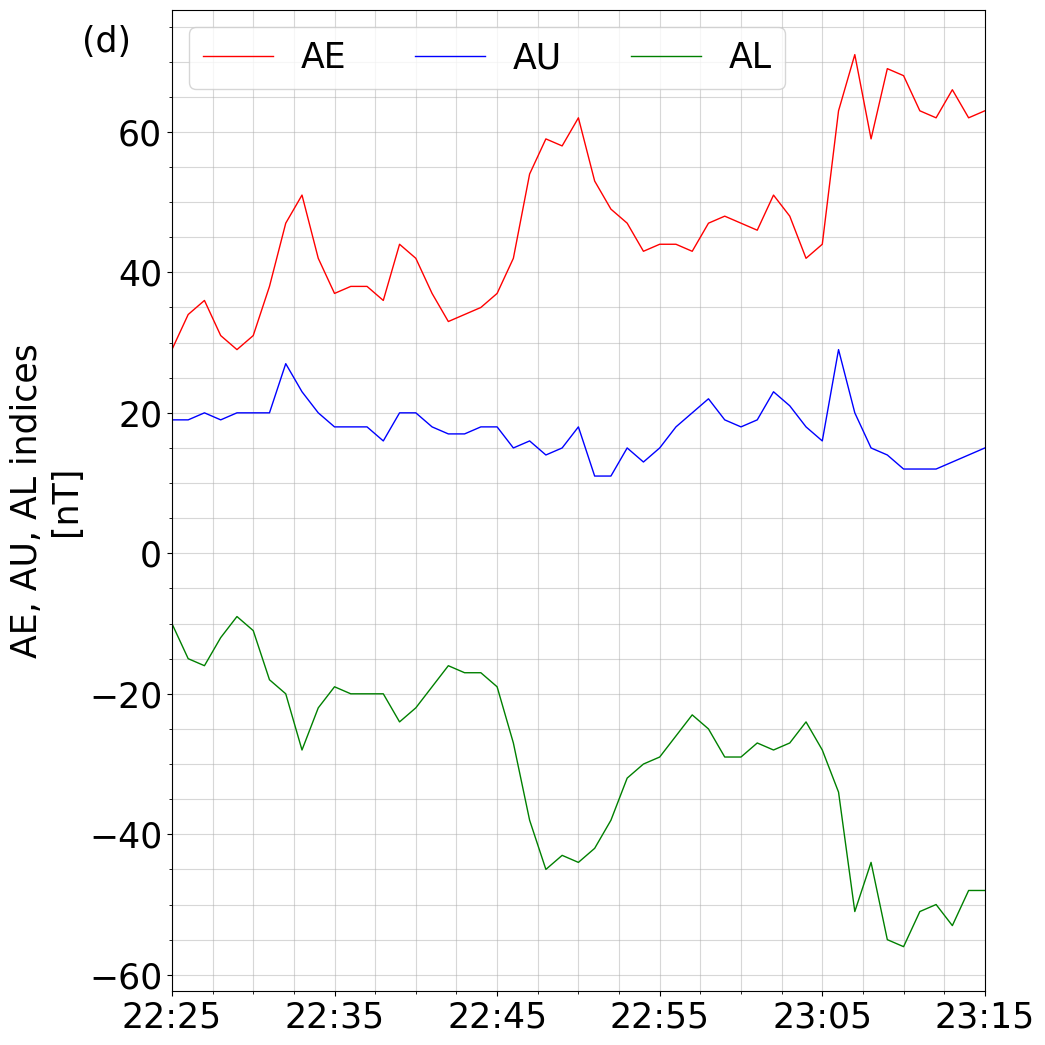

In [71]:
from datetime import datetime

time_range_analysis     = ['20220901/22:25:00', '20220901/23:15:00']
time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]

da_sym_h_analysis       = da_sym_h.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
da_ae_index_analysis    = da_ae_index.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
da_au_index_analysis    = da_au_index.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
da_al_index_analysis    = da_al_index.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))

fig = plt.figure(figsize=(11, 11))

gs      = fig.add_gridspec(1, 1)
ax_0    = fig.add_subplot(gs[0, 0])

#ax_0.tick_params(axis='x', which='both', labelbottom=False)

ax_0.plot(da_ae_index_analysis.time,    da_ae_index_analysis.data,  lw=1, c='r',        label='AE')
ax_0.plot(da_au_index_analysis.time,    da_au_index_analysis.data,  lw=1, c='b',        label='AU')
ax_0.plot(da_al_index_analysis.time,    da_al_index_analysis.data,  lw=1, c='green',    label='AL')

ax_0.set_ylabel(r'AE, AU, AL indices'   + '\n' + '[nT]')

ax_0.minorticks_on()
ax_0.grid(which='both', alpha=0.5)

ax_0.legend(ncol=3)

to_npdt = lambda s: np.datetime64(datetime.strptime(s, '%Y%m%d/%H:%M:%S'))
time_range_T_analysis_0, time_range_T_analysis_1 = map(to_npdt, time_range_analysis)
ax_0.set_xlim(time_range_T_analysis_0, time_range_T_analysis_1)
ax_0.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax_0.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))

add_panel_label(ax_0, '(d)', -0.05)

fig.tight_layout()

plt.show(fig)
fig.savefig(r"/mnt/j/KAW_observation/Figure_1_b.pdf", bbox_inches='tight')
fig.savefig(r"/mnt/j/KAW_observation/Figure_1_b.png", bbox_inches='tight')

# HFAのplot

In [ ]:
psp.erg.pwe_hfa(trange=time_range, level='l2', no_update=True)
psp.erg.pwe_hfa(trange=time_range, level='l3', no_update=True)
psp.erg.mgf(trange=time_range, level='l2', datatype='64hz', no_update=True)

In [ ]:
B_total = np.sqrt(pt.data_quants['erg_mgf_l2_mag_64hz_dsi'].isel(v_dim=0)**2E0 + pt.data_quants['erg_mgf_l2_mag_64hz_dsi'].isel(v_dim=1)**2E0 + pt.data_quants['erg_mgf_l2_mag_64hz_dsi'].isel(v_dim=2)**2E0)
dt = (B_total.time[1] - B_total.time[0]) / np.timedelta64(1, 's')
B_total = B_total.rolling(time=int(100 / dt), center=True).mean('time')

ep_0 = 8.8541878188E-12 #[A^2 s^4 / kg / m^3]
m_e  = 9.1093837E-31    #[kg]
elementary_charge = 1.60217663E-19  #[A s]

n_e = pt.data_quants['erg_pwe_hfa_l3_1min_ne_mgf'].interp(time=B_total.time, method='linear')

f_ce = elementary_charge * B_total*1E-9 / m_e / 2 / np.pi / 1E3                     # [kHz]
f_pe = np.sqrt(n_e*1E6 * elementary_charge**2E0 / m_e / ep_0) / 2 / np.pi / 1E3     # [kHz]

f_UHR = np.sqrt(f_ce**2E0 + f_pe**2E0)  # [kHz]

da_f_UHR    = xr.DataArray(data=f_UHR, dims=['time'], coords={'time': B_total.time}, name='f_UHR')
da_f_ce     = xr.DataArray(data=f_ce,  dims=['time'], coords={'time': B_total.time}, name='f_ce')
da_f_pe     = xr.DataArray(data=f_pe,  dims=['time'], coords={'time': B_total.time}, name='f_pe')

In [ ]:
da_hfa_spectral = pt.data_quants['erg_pwe_hfa_l2_low_spectra_esum']
da_hfa_spectral

In [ ]:
from datetime import datetime
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm


time_range_analysis     = ['20220901/22:25:00', '20220901/23:25:00']
time_range_T_analysis   = [time_range_analysis[0].replace('/', 'T'), time_range_analysis[1].replace('/', 'T')]

da_hfa_spectral_analysis    = da_hfa_spectral.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
da_f_UHR_analysis           = da_f_UHR.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
da_f_ce_analysis            = da_f_ce.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))
da_f_pe_analysis            = da_f_pe.sel(time=slice(time_range_T_analysis[0], time_range_T_analysis[1]))

fig = plt.figure(figsize=(12, 5))

ax_0    = fig.add_subplot(111)

T_0 = mdates.date2num(da_hfa_spectral_analysis.time.values)
F_0 = da_hfa_spectral_analysis.spec_bins.values
Z_0 = da_hfa_spectral_analysis.values.astype(float)

T_0_m = np.tile(T_0, (F_0.size, 1)).T
F_0_m = np.tile(F_0, (T_0.size, 1))

pcm = ax_0.pcolormesh(T_0_m, F_0_m, Z_0, shading='auto', norm=LogNorm(vmin=1E-8, vmax=1E-4), cmap='turbo')
ax_0.plot(da_f_UHR_analysis.time, da_f_UHR_analysis.data, c='white', lw=2)
ax_0.minorticks_on()
#ax_0.set_yscale('log')
ax_0.set_ylim(5E0, 3E1)
ax_0.set_ylabel('PWE-HFA [kHz]')
ax_0.grid(which='both', alpha=0.5)

#ax_1.legend(ncol=3, fontsize=15)

to_npdt = lambda s: np.datetime64(datetime.strptime(s, '%Y%m%d/%H:%M:%S'))
time_range_T_analysis_0, time_range_T_analysis_1 = map(to_npdt, time_range_analysis)
ax_0.set_xlim(time_range_T_analysis_0, time_range_T_analysis_1)

cax = ax_0.inset_axes([1.01, 0.05, 0.02, 0.9])
cb = plt.colorbar(pcm, cax=cax)
cb.minorticks_on()
cb.set_label(r'$[\mathrm{(mV/m)}^{2} / \mathrm{Hz}]$')

fig.tight_layout()

plt.show(fig)